# MACHINE LEARNING ORIENTED EDA
## Dự đoán Giá Bất Động Sản TP.HCM

Mục tiêu EDA: phục vụ **prediction accuracy**, không chỉ mô tả dữ liệu.
- Kiểm tra assumption của model
- Phân tích distribution & skewness
- Phát hiện & phân tích outlier
- Hỗ trợ feature engineering
- Hỗ trợ model selection & feature selection

---
## CELL 0 — Setup: Import & Load Data

In [ ]:
# ============================================================
# CELL 0: Import & Load
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, jarque_bera
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

# ── Load ──────────────────────────────────────────────────
!gdown https://drive.google.com/uc?id=1jxI2vKoEc5p2GmOGBB2kqLv_nO5PyBwv
df = pd.read_csv('data_final.csv')

# Derived columns
df['price_total_vnd']  = df['price_total_vnd'].astype(float)
df['price_per_m2_vnd'] = df['price_per_m2_vnd'].astype(float)
df['price_ty']         = df['price_total_vnd'] / 1e9           # tỷ VND
df['price_m2']         = df['price_per_m2_vnd'] / 1e6          # triệu/m²  ← TARGET
df['log_price_m2']     = np.log1p(df['price_m2'])              # log target
df['log_price_total']  = np.log1p(df['price_ty'])
df['log_area']         = np.log1p(df['area_m2'])

print('Load thành công!')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} cols')
df.head(2)

Downloading...
From: https://drive.google.com/uc?id=1jxI2vKoEc5p2GmOGBB2kqLv_nO5PyBwv
To: /content/data_final.csv
100% 67.1M/67.1M [00:00<00:00, 74.2MB/s]
Load thành công!
Shape: 6,435 rows × 60 cols


,source_name,snapshot_date,source_listing_id,listing_url,project_name,listing_type,title,listing_description,price_total_vnd,area_m2,...,handover_year,ownership,project_description,source_url,note,price_ty,price_m2,log_price_m2,log_price_total,log_area
0,batdongsan,4/26/2026 8:33,45564207,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,De La Sol,vip-silver,"Căn đẹp nhất De-La-Sol của Capital Singapore, ...",* Bán căn hộ đẹp nhất dự án De - La - Sol của ...,1.440000e+10,111.0,...,2023.0,Sổ hồng lâu dài,De La Sol là dự án căn hộ hạng sang tọa lạc ng...,https://batdongsan.com.vn/du-an-can-ho-chung-c...,NaN,14.4,129.729730,4.873132,2.734368,4.718499
1,batdongsan,4/26/2026 8:33,45184097,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,De La Sol,vip-silver,"Nắm full giỏ hàng độc quyền Delasol, Quận 4 1P...","Bên em tổng hợp rất nhiều căn 1,2,3PN tại dự á...",8.500000e+09,75.0,...,2023.0,Sổ hồng lâu dài,De La Sol là dự án căn hộ hạng sang tọa lạc ng...,https://batdongsan.com.vn/du-an-can-ho-chung-c...,NaN,8.5,113.333333,4.739118,2.251292,4.330733


---
## SECTION 1 — DATASET OVERVIEW

### Cell 1A — Shape, DTypes, Numerical vs Categorical

In [ ]:
# ============================================================
# CELL 1A: Dataset Overview — DTypes & Feature Classification
# ============================================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include='object').columns
            if c not in ['listing_url','title','listing_description',
                         'contact_name','contact_phone_masked','address',
                         'project_description','source_url','note',
                         'posted_at','expired_at','snapshot_date']]
bin_cols = ['has_mall','has_school','has_hospital','has_park','has_pool','has_parkinglot']

print('='*65)
print(f'  DATASET SHAPE: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('='*65)
print(f'\nNumerical features  : {len(num_cols)}')
print(f'Categorical features : {len(cat_cols)}')
print(f'Binary (has_*)       : {len(bin_cols)}')
print(f'Duplicate rows       : {df.duplicated().sum()}')

print('\nNUMERICAL FEATURES:')
for c in num_cols:
    print(f'   {c}')

print('\nUSABLE CATEGORICAL FEATURES:')
for c in cat_cols:
    n_uniq = df[c].nunique()
    print(f'   {c:<30} unique={n_uniq}')

print()

  DATASET SHAPE: 6,435 rows × 60 columns

Numerical features  : 34
Categorical features : 14
Binary (has_*)       : 6
Duplicate rows       : 0

NUMERICAL FEATURES:
   source_listing_id
   price_total_vnd
   area_m2
   price_per_m2_vnd
   bedrooms
   bathrooms
   longitude
   latitude
   land_area_ha
   num_towers
   total_apartment
   construction_density
   dist_cbd_km
   dist_metro_km
   dist_river_lake_km
   dist_highway_km
   dist_airport_km
   dist_market
   dist_school
   dist_park
   dist_hospital
   has_mall
   has_school
   has_hospital
   has_park
   has_pool
   has_parkinglot
   launch_year
   handover_year
   price_ty
   price_m2
   log_price_m2
   log_price_total
   log_area

USABLE CATEGORICAL FEATURES:
   source_name                    unique=3
   project_name                   unique=83
   listing_type                   unique=5
   legal_status                   unique=3
   furniture_status               unique=4
   direction                      unique=9
   project_id 

### Cell 1B — Missing Values Analysis

,Feature,Null_Count,Null_%,ML_Impact
0,note,6334,98.4,🔴 Critical | DROP
1,contact_phone_masked,1323,20.6,🟠 High | Impute + Flag
2,num_towers,1297,20.2,🟠 High | Impute + Flag
3,expired_at,818,12.7,🟡 Medium | Median/Mode
4,launch_year,469,7.3,🟡 Medium | Median/Mode
5,construction_density,342,5.3,🟡 Medium | Median/Mode
6,street,293,4.6,🟢 Low | Simple Impute
7,total_apartment,275,4.3,🟢 Low | Simple Impute
8,handover_year,241,3.7,🟢 Low | Simple Impute
9,ownership,229,3.6,🟢 Low | Simple Impute


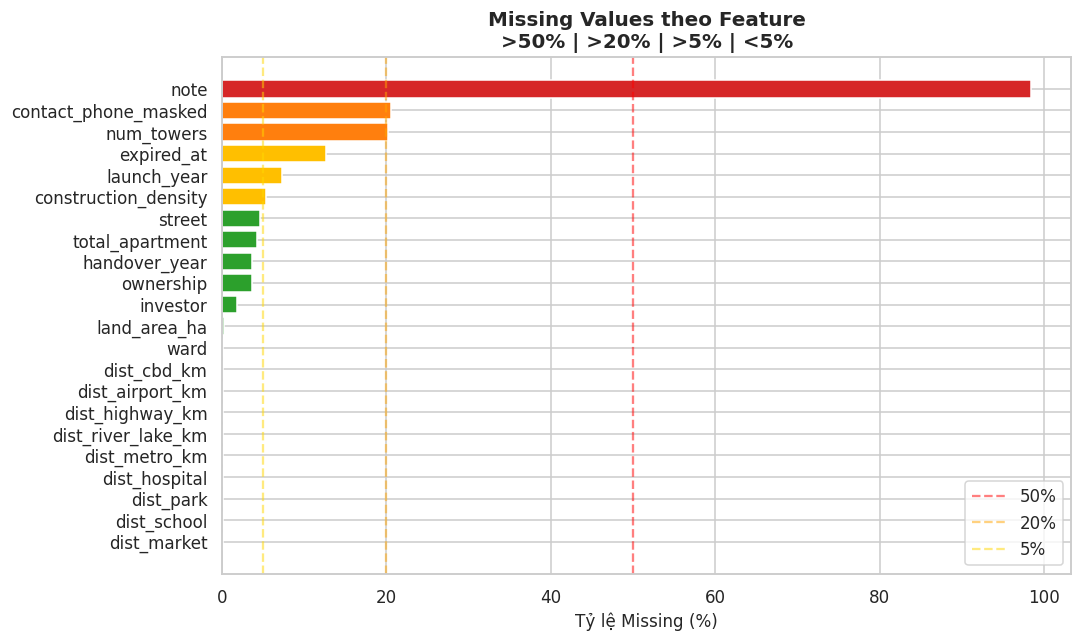

In [ ]:
# ============================================================
# CELL 1B: Missing Values — ML Impact
# ============================================================
null_info = df.isnull().sum().reset_index()
null_info.columns = ['Feature', 'Null_Count']
null_info['Null_%'] = (null_info['Null_Count'] / len(df) * 100).round(1)
null_info = null_info[null_info['Null_Count'] > 0].sort_values('Null_%', ascending=False)

# Phân loại mức độ ảnh hưởng
def classify_missing(pct):
    if pct > 50:
        return '🔴 Critical | DROP'
    elif pct > 20:
        return '🟠 High | Impute + Flag'
    elif pct > 5:
        return '🟡 Medium | Median/Mode'
    return '🟢 Low | Simple Impute'

null_info['ML_Impact'] = null_info['Null_%'].apply(classify_missing)
display(
    null_info[
        ['Feature', 'Null_Count', 'Null_%', 'ML_Impact']
    ].reset_index(drop=True)
)

# Biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if p>50 else '#ff7f0e' if p>20 else '#ffbf00' if p>5 else '#2ca02c'
          for p in null_info['Null_%']]
bars = ax.barh(null_info['Feature'][::-1], null_info['Null_%'][::-1], color=colors[::-1])
ax.set_xlabel('Tỷ lệ Missing (%)', fontsize=11)
ax.set_title('Missing Values theo Feature\n>50% | >20% | >5% | <5%', fontsize=13, fontweight='bold')
ax.axvline(50, color='red',    linestyle='--', alpha=0.5, label='50%')
ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='20%')
ax.axvline(5,  color='gold',   linestyle='--', alpha=0.5, label='5%')
ax.legend()
plt.tight_layout()
plt.show()

---
## SECTION 2 — DISTRIBUTION ANALYSIS

### Cell 2A — Target Distribution: price_per_m2 (Raw vs Log)

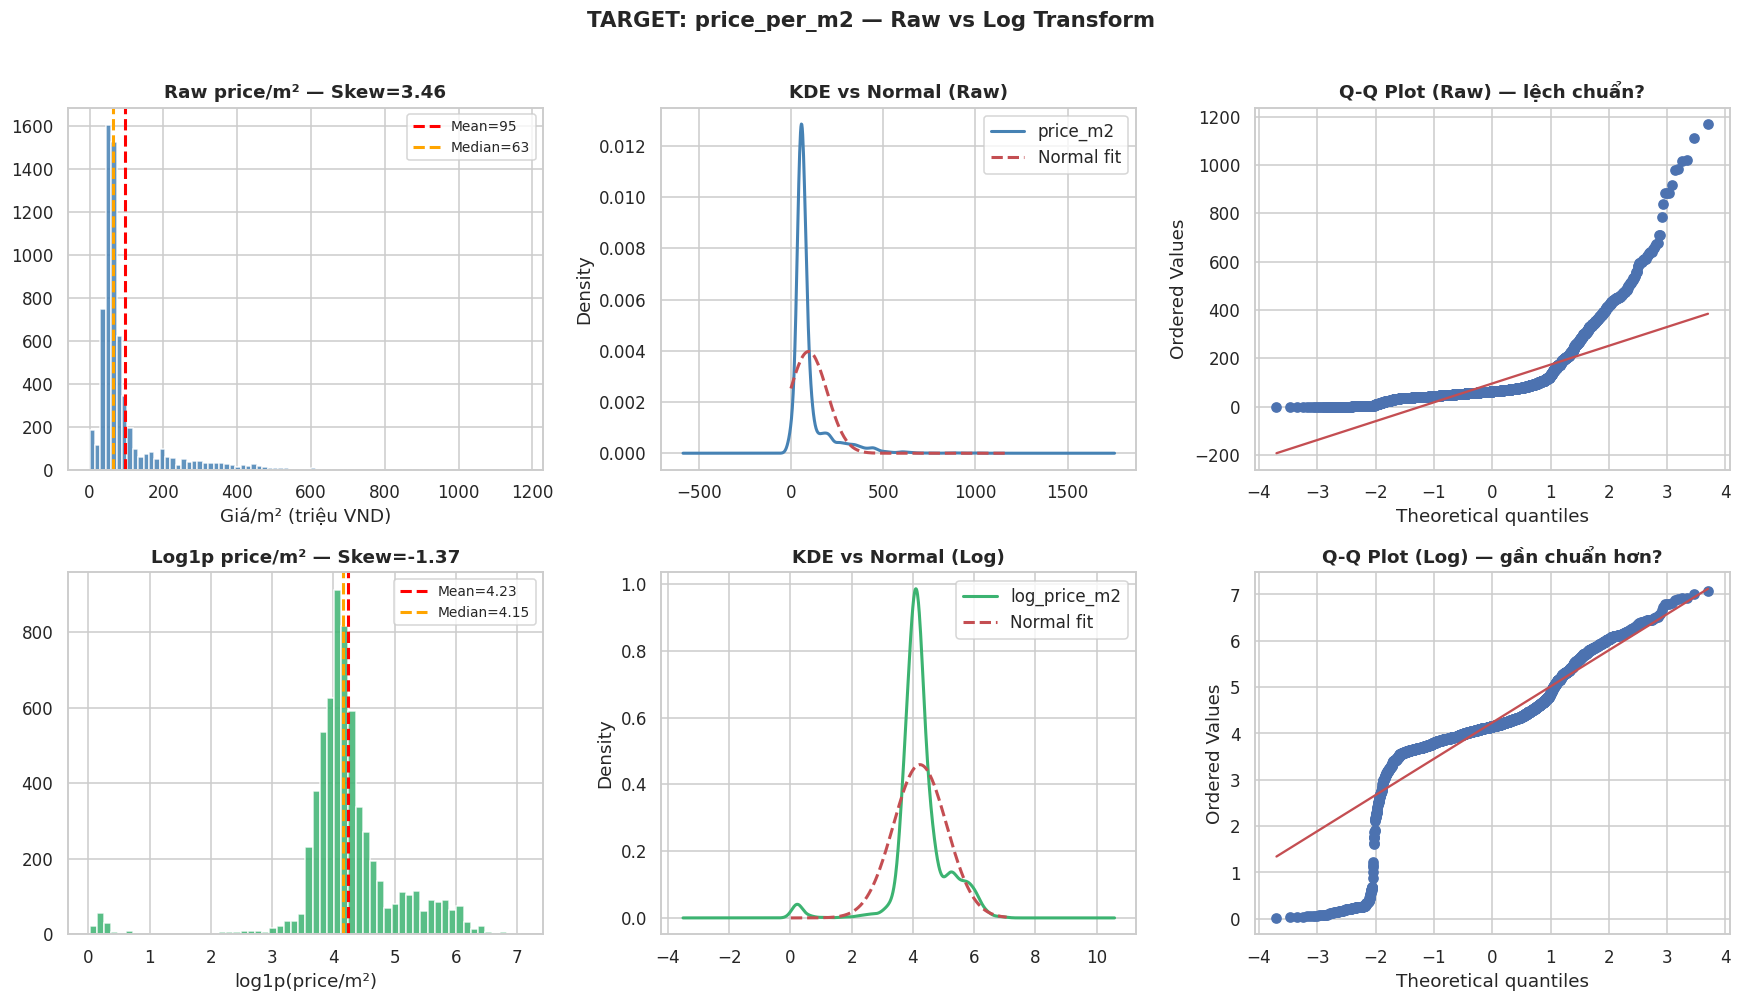

NORMALITY TEST (Jarque-Bera)
  Raw  price/m² → skew=3.46, p=0.0000 NOT normal
  Log1p price/m² → skew=-1.37, p=0.0000 NOT normal


In [ ]:
# ============================================================
# CELL 2A: Target Distribution — Raw vs Log Transform
# ============================================================
target_raw = df['price_m2'].dropna()
target_log = df['log_price_m2'].dropna()

sk_raw = target_raw.skew()
sk_log = target_log.skew()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── RAW ────────────────────────────────────────
axes[0,0].hist(target_raw, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(target_raw.mean(),   color='red',    ls='--', lw=2, label=f'Mean={target_raw.mean():.0f}')
axes[0,0].axvline(target_raw.median(), color='orange', ls='--', lw=2, label=f'Median={target_raw.median():.0f}')
axes[0,0].set_title(f'Raw price/m² — Skew={sk_raw:.2f}', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Giá/m² (triệu VND)')
axes[0,0].legend(fontsize=9)

# KDE raw
target_raw.plot(kind='kde', ax=axes[0,1], color='steelblue', lw=2)
x = np.linspace(target_raw.min(), target_raw.max(), 200)
mu, sigma = target_raw.mean(), target_raw.std()
axes[0,1].plot(x, stats.norm.pdf(x, mu, sigma), 'r--', lw=2, label='Normal fit')
axes[0,1].set_title('KDE vs Normal (Raw)', fontsize=12, fontweight='bold')
axes[0,1].legend()

# QQ raw
stats.probplot(target_raw, dist='norm', plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot (Raw) — lệch chuẩn?', fontsize=12, fontweight='bold')

# ── LOG ────────────────────────────────────────
axes[1,0].hist(target_log, bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1,0].axvline(target_log.mean(),   color='red',    ls='--', lw=2, label=f'Mean={target_log.mean():.2f}')
axes[1,0].axvline(target_log.median(), color='orange', ls='--', lw=2, label=f'Median={target_log.median():.2f}')
axes[1,0].set_title(f'Log1p price/m² — Skew={sk_log:.2f}', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('log1p(price/m²)')
axes[1,0].legend(fontsize=9)

# KDE log
target_log.plot(kind='kde', ax=axes[1,1], color='mediumseagreen', lw=2)
mu2, sigma2 = target_log.mean(), target_log.std()
x2 = np.linspace(target_log.min(), target_log.max(), 200)
axes[1,1].plot(x2, stats.norm.pdf(x2, mu2, sigma2), 'r--', lw=2, label='Normal fit')
axes[1,1].set_title('KDE vs Normal (Log)', fontsize=12, fontweight='bold')
axes[1,1].legend()

# QQ log
stats.probplot(target_log, dist='norm', plot=axes[1,2])
axes[1,2].set_title('Q-Q Plot (Log) — gần chuẩn hơn?', fontsize=12, fontweight='bold')

plt.suptitle('TARGET: price_per_m2 — Raw vs Log Transform', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Normality tests
sample = target_raw.sample(min(5000, len(target_raw)), random_state=42)
_, p_jb_raw = jarque_bera(sample)
sample_log = target_log.sample(min(5000, len(target_log)), random_state=42)
_, p_jb_log = jarque_bera(sample_log)

print('='*55)
print('NORMALITY TEST (Jarque-Bera)')
print(f'  Raw  price/m² → skew={sk_raw:.2f}, p={p_jb_raw:.4f} {"NOT normal" if p_jb_raw<0.05 else "Normal"}')
print(f'  Log1p price/m² → skew={sk_log:.2f}, p={p_jb_log:.4f} {"NOT normal" if p_jb_log<0.05 else "Normal"}')

### Cell 2B — Numerical Features: Skewness & Distribution

,Feature,Skewness,Kurtosis,Null_%,Distribution
0,area_m2,8.21,160.28,0.00,🔴 Highly Skewed | Log Transform
1,bathrooms,4.02,40.82,0.00,🔴 Highly Skewed | Log Transform
2,dist_river_lake_km,2.98,11.60,0.08,🔴 Highly Skewed | Log Transform
3,bedrooms,2.92,31.73,0.00,🔴 Highly Skewed | Log Transform
4,dist_market,2.47,9.04,0.08,🔴 Highly Skewed | Log Transform
5,construction_density,2.44,10.69,5.31,🔴 Highly Skewed | Log Transform
6,dist_school,1.58,3.63,0.08,🟠 Moderate | Consider Transform
7,dist_highway_km,1.33,1.62,0.12,🟠 Moderate | Consider Transform
8,dist_hospital,1.10,1.37,0.08,🟠 Moderate | Consider Transform
9,land_area_ha,0.86,-1.17,0.22,🟡 Slight | Acceptable


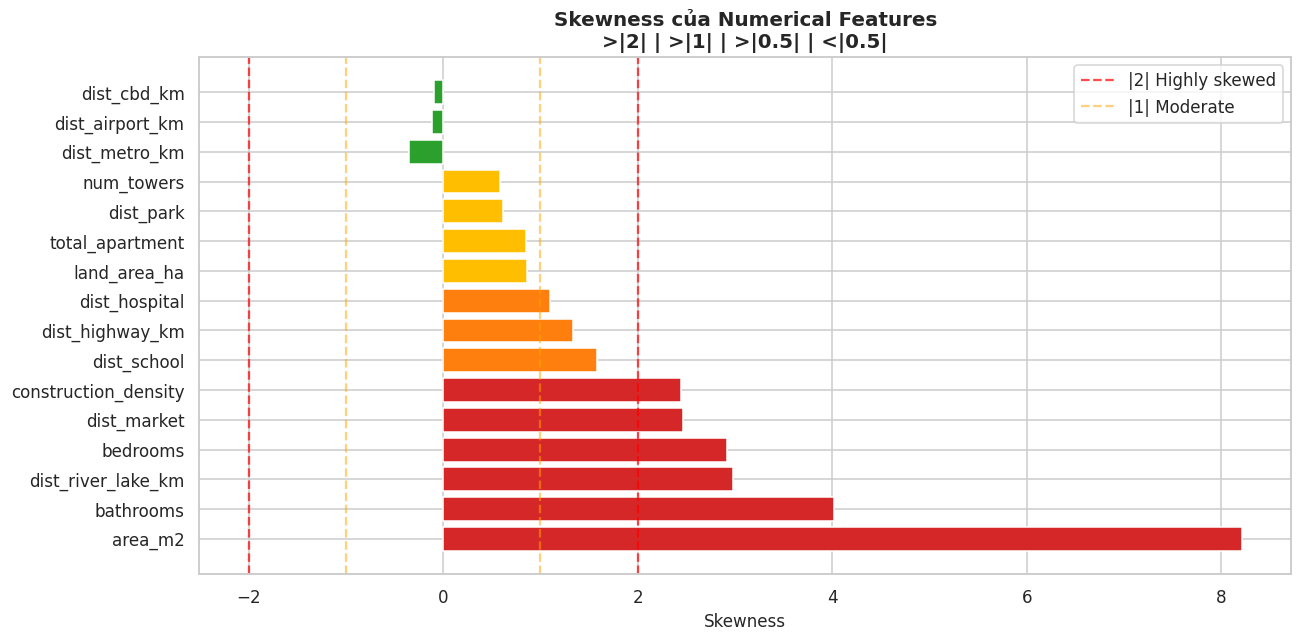


Features cần log transform: ['area_m2', 'bathrooms', 'dist_river_lake_km', 'bedrooms', 'dist_market', 'construction_density']


In [ ]:
# ============================================================
# CELL 2B: Skewness Analysis — tất cả numerical features
# ============================================================
key_features = [
    'area_m2', 'bedrooms', 'bathrooms',
    'dist_cbd_km', 'dist_metro_km', 'dist_river_lake_km',
    'dist_highway_km', 'dist_airport_km', 'dist_market',
    'dist_school', 'dist_park', 'dist_hospital',
    'land_area_ha', 'num_towers', 'total_apartment', 'construction_density'
]

skew_df = pd.DataFrame({
    'Feature': key_features,
    'Skewness': [df[c].skew() for c in key_features],
    'Kurtosis': [df[c].kurtosis() for c in key_features],
    'Null_%': [df[c].isnull().mean()*100 for c in key_features]
}).sort_values('Skewness', ascending=False, key=abs)

def skew_label(s):
    if abs(s) > 2:
        return '🔴 Highly Skewed | Log Transform'
    elif abs(s) > 1:
        return '🟠 Moderate | Consider Transform'
    elif abs(s) > 0.5:
        return '🟡 Slight | Acceptable'
    return '🟢 Symmetric | OK'

skew_df['Distribution'] = skew_df['Skewness'].apply(skew_label)
skew_df[['Skewness', 'Kurtosis', 'Null_%']] = (
    skew_df[['Skewness', 'Kurtosis', 'Null_%']]
    .round(2)
)

display(
    skew_df[
        ['Feature', 'Skewness', 'Kurtosis',
         'Null_%', 'Distribution']
    ]
    .reset_index(drop=True)
    )

# Biểu đồ skewness
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if abs(s)>2 else '#ff7f0e' if abs(s)>1 else '#ffbf00' if abs(s)>0.5 else '#2ca02c'
          for s in skew_df['Skewness']]
ax.barh(skew_df['Feature'], skew_df['Skewness'], color=colors)
ax.axvline(2,  color='red',    ls='--', alpha=0.7, label='|2| Highly skewed')
ax.axvline(-2, color='red',    ls='--', alpha=0.7)
ax.axvline(1,  color='orange', ls='--', alpha=0.5, label='|1| Moderate')
ax.axvline(-1, color='orange', ls='--', alpha=0.5)
ax.set_xlabel('Skewness', fontsize=11)
ax.set_title('Skewness của Numerical Features\n>|2| | >|1| | >|0.5| | <|0.5|', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

highly_skewed = skew_df[abs(skew_df['Skewness']) > 2]['Feature'].tolist()
print(f'\nFeatures cần log transform: {highly_skewed}')

### Cell 2C — Log Transform: Before vs After (Highly Skewed Features)

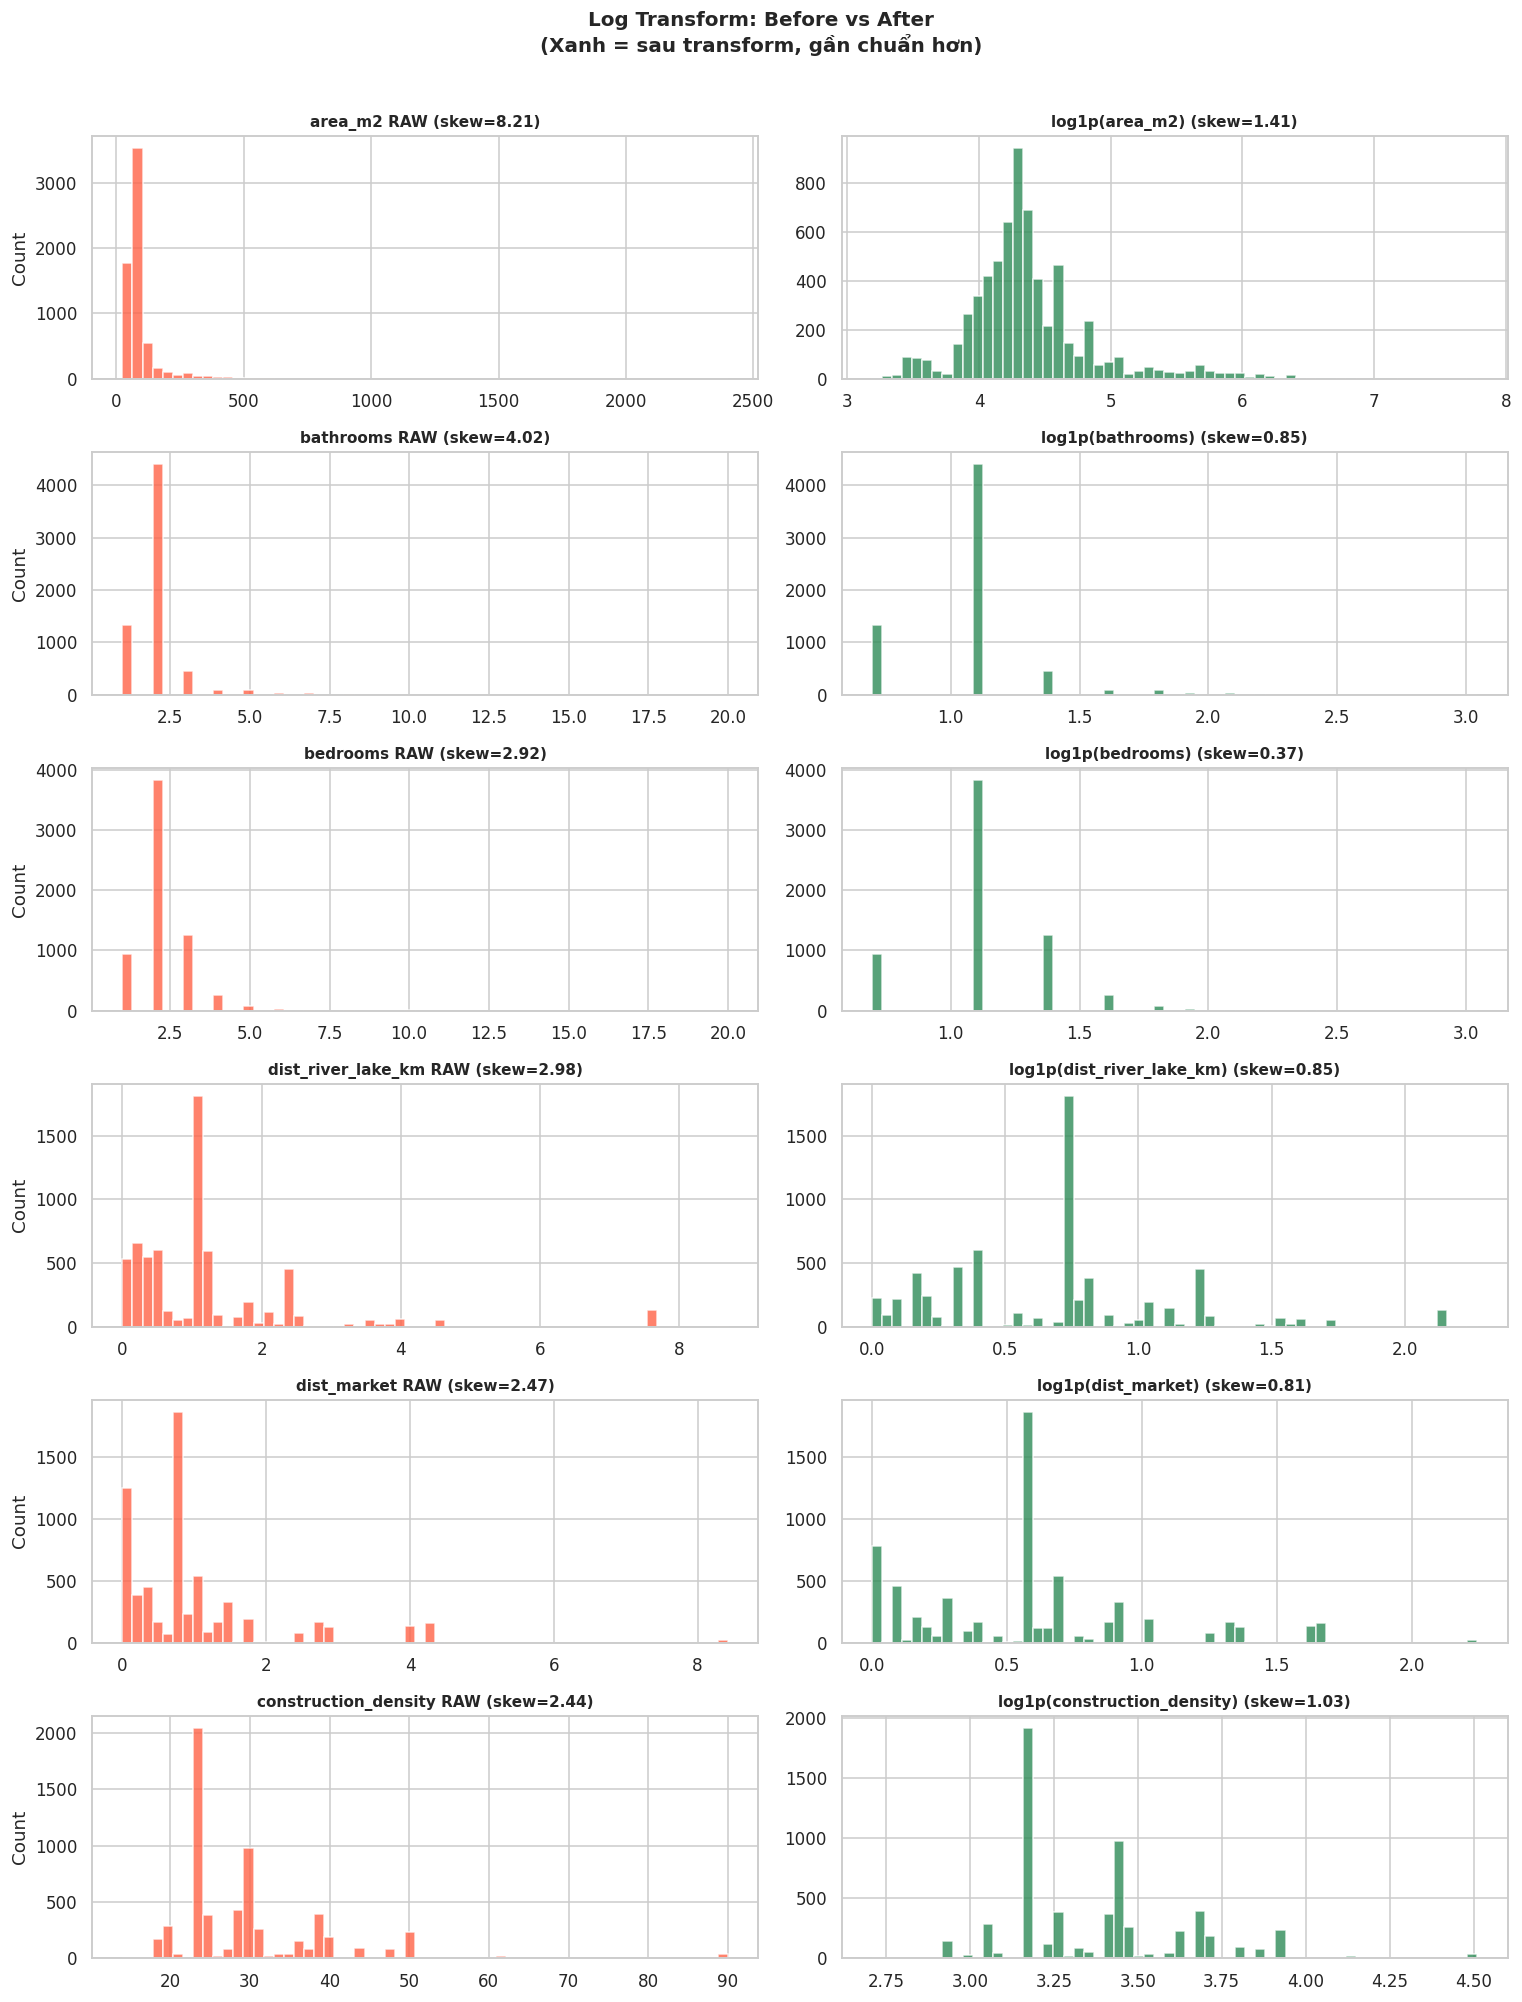

In [ ]:
# ============================================================
# CELL 2C: Log Transform Visualization — Before vs After
# ============================================================
highly_skewed = ['area_m2', 'bathrooms', 'bedrooms', 'dist_river_lake_km',
                 'dist_market', 'construction_density']
# Chỉ lấy các cột thực sự tồn tại và skew > 2
to_transform = [c for c in highly_skewed if c in df.columns and abs(df[c].skew()) > 1]

n = len(to_transform)
fig, axes = plt.subplots(n, 2, figsize=(14, n * 3))

for i, col in enumerate(to_transform):
    data = df[col].dropna()
    log_data = np.log1p(data)

    axes[i, 0].hist(data, bins=60, color='tomato', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col} RAW (skew={data.skew():.2f})', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].hist(log_data, bins=60, color='seagreen', edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'log1p({col}) (skew={log_data.skew():.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Log Transform: Before vs After\n(Xanh = sau transform, gần chuẩn hơn)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Cell 2D — Boxplot Tổng hợp các Numerical Features

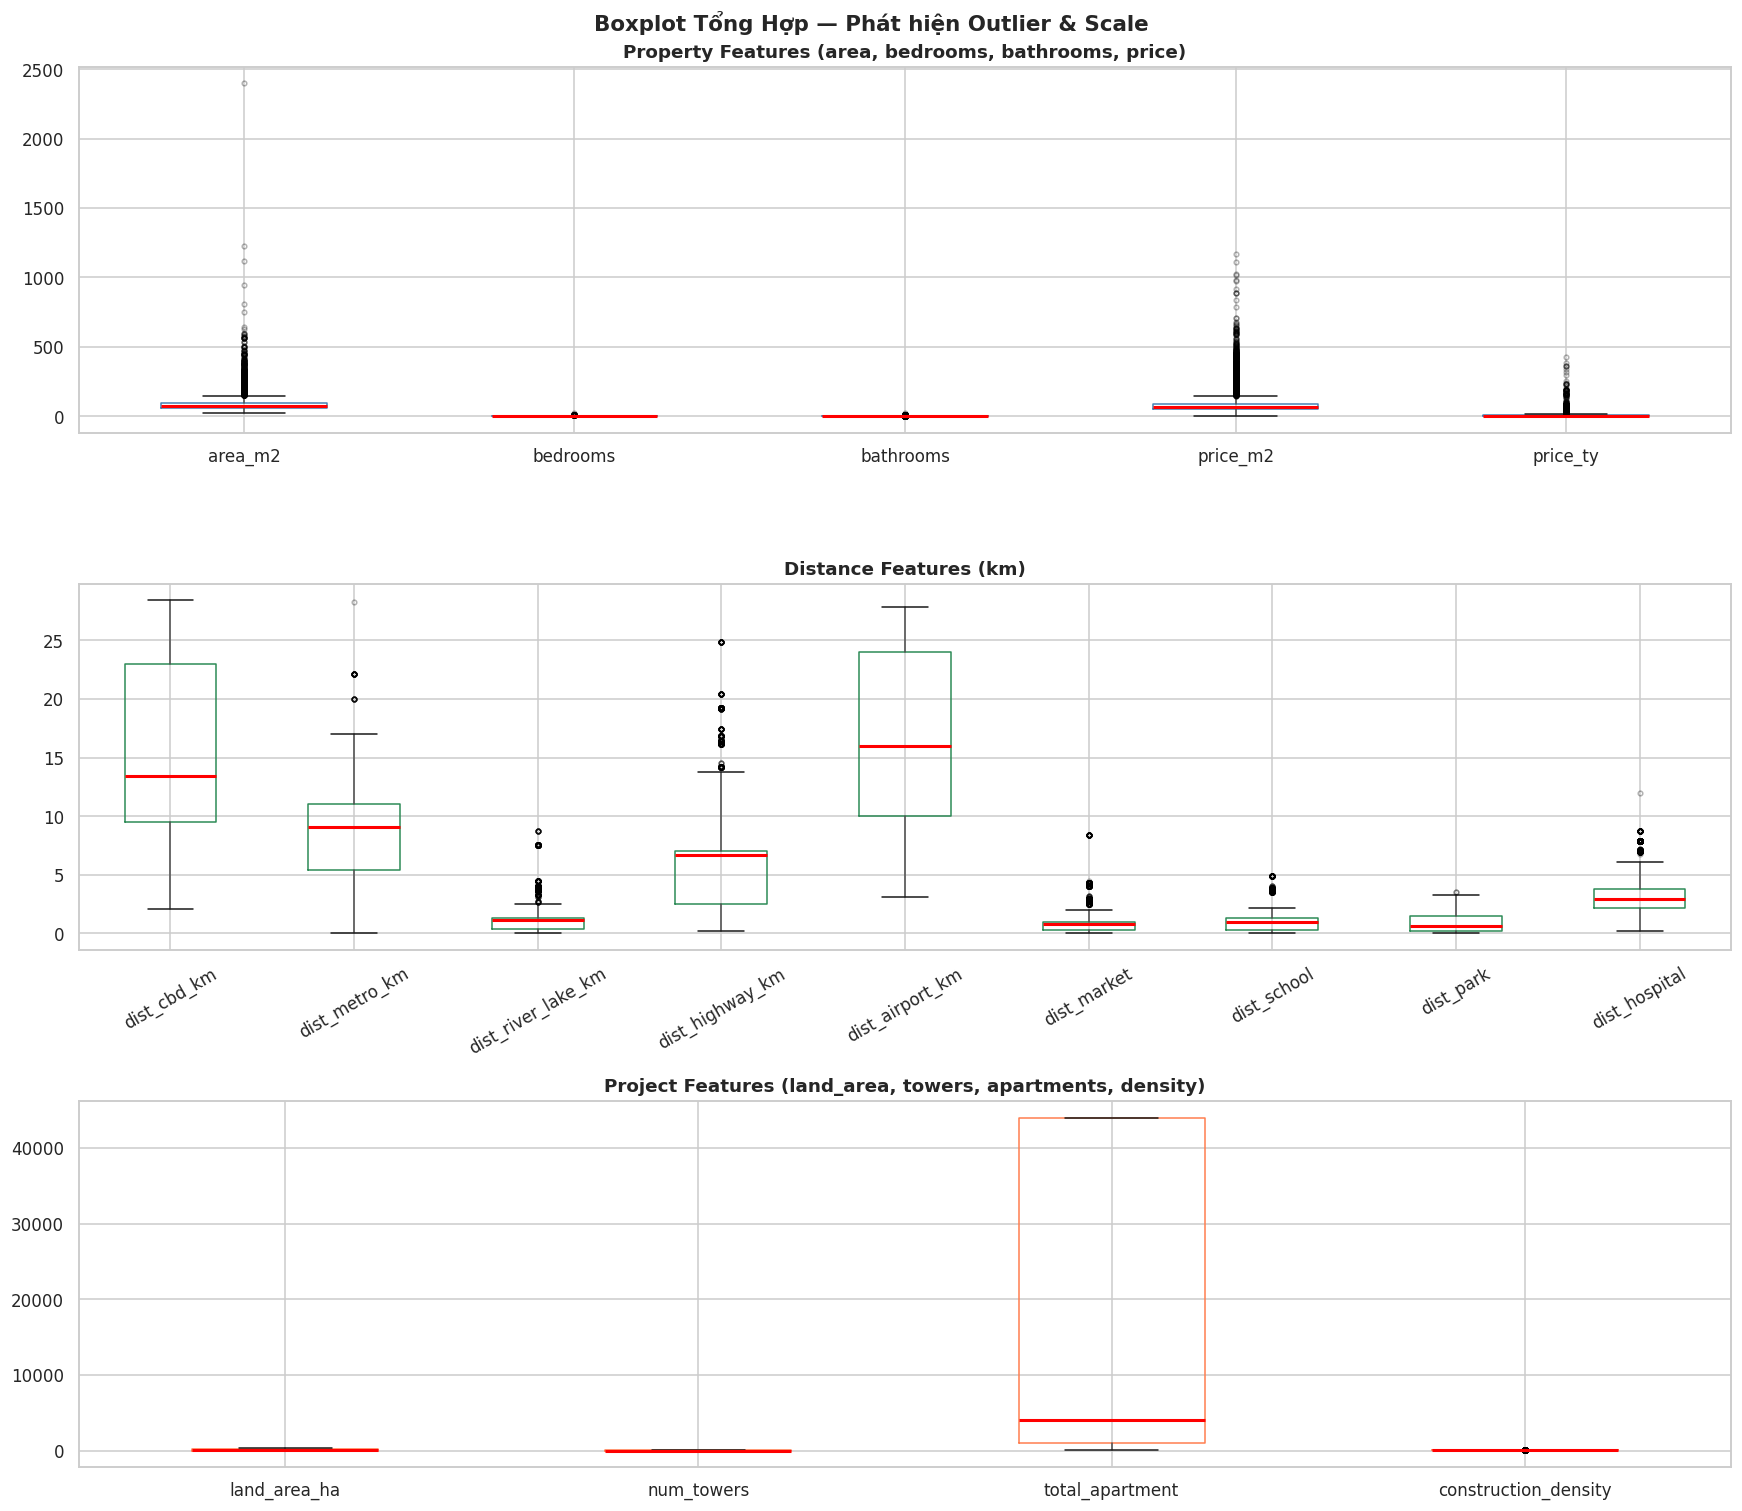

In [ ]:
# ============================================================
# CELL 2D: Boxplot — tất cả features chính
# ============================================================
dist_features = ['dist_cbd_km','dist_metro_km','dist_river_lake_km',
                 'dist_highway_km','dist_airport_km','dist_market',
                 'dist_school','dist_park','dist_hospital']
prop_features = ['area_m2','bedrooms','bathrooms','price_m2','price_ty']
proj_features = ['land_area_ha','num_towers','total_apartment','construction_density']

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

df[prop_features].boxplot(ax=axes[0],
    boxprops=dict(color='steelblue'), medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='o', alpha=0.3, markersize=3, color='steelblue'))
axes[0].set_title('Property Features (area, bedrooms, bathrooms, price)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

df[dist_features].boxplot(ax=axes[1],
    boxprops=dict(color='seagreen'), medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='o', alpha=0.3, markersize=3, color='seagreen'))
axes[1].set_title('Distance Features (km)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

df[proj_features].boxplot(ax=axes[2],
    boxprops=dict(color='coral'), medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='o', alpha=0.3, markersize=3, color='coral'))
axes[2].set_title('Project Features (land_area, towers, apartments, density)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Boxplot Tổng Hợp — Phát hiện Outlier & Scale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## SECTION 3 — OUTLIER ANALYSIS

### Cell 3A — Global Outlier: IQR + Z-Score + Quantile (Toàn Bộ Data)

Feature,N,IQR_outliers,IQR_%,Zscore_outliers,Z_%,Q1-99_outliers,Q_%
price_m2,6435,943,14.7%,169,2.6%,127,2.0%
price_ty,6435,917,14.3%,88,1.4%,122,1.9%
area_m2,6435,540,8.4%,154,2.4%,93,1.4%


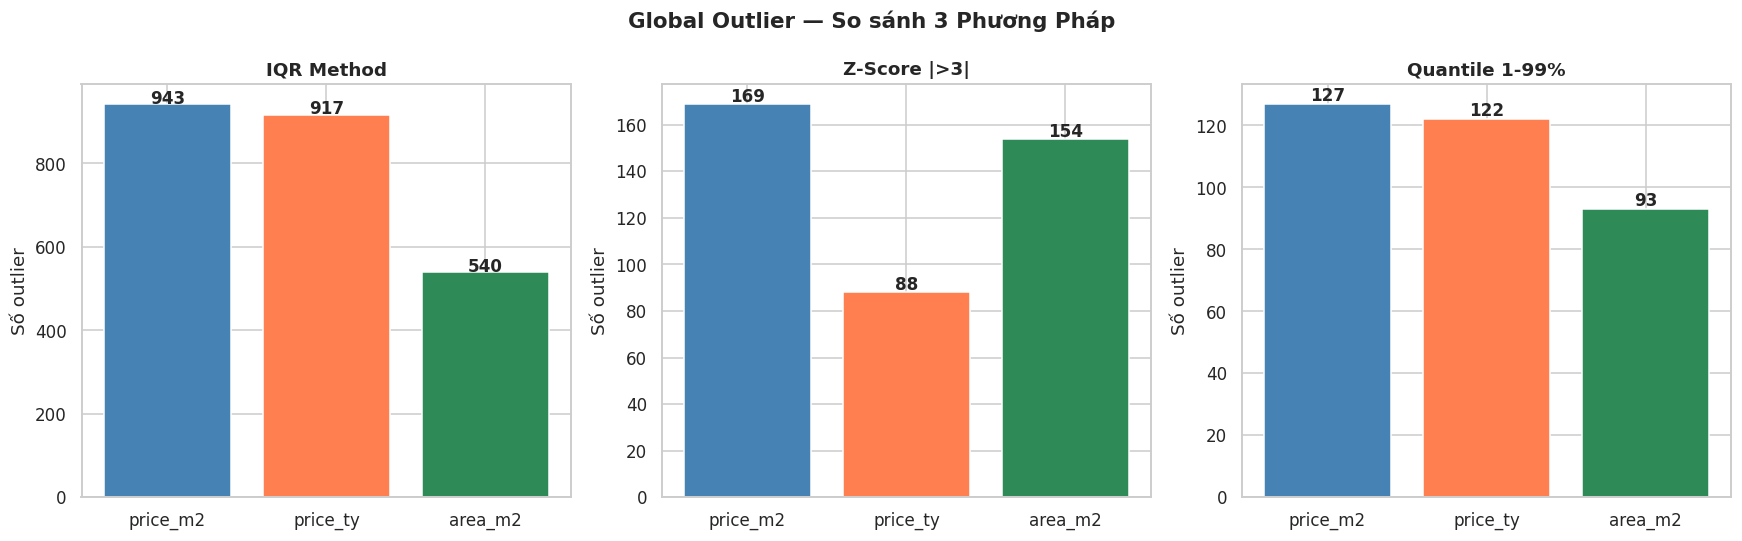

In [ ]:
# ============================================================
# CELL 3A: Global Outlier Detection — 3 phương pháp
# ============================================================
target_cols = ['price_m2', 'price_ty', 'area_m2']

results = []
for col in target_cols:
    data = df[col].dropna()
    n = len(data)

    # IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()

    # Z-score
    z = np.abs(stats.zscore(data))
    z_out = (z > 3).sum()

    # Quantile 1-99%
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    q_out = ((data < lo) | (data > hi)).sum()

    results.append({
        'Feature': col,
        'N': n,
        'IQR_outliers': iqr_out, 'IQR_%': f'{iqr_out/n*100:.1f}%',
        'Zscore_outliers': z_out, 'Z_%': f'{z_out/n*100:.1f}%',
        'Q1-99_outliers': q_out, 'Q_%': f'{q_out/n*100:.1f}%',
    })

res_df = pd.DataFrame(results)
display(res_df.style
        .hide(axis='index')
        .set_caption('Global Outlier Detection — So sánh 3 phương pháp')
        .set_properties(**{
            'text-align': 'center',
            'padding': '6px'
        }))

# Visualize: 3 phương pháp so sánh
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = [('IQR_outliers','IQR Method'), ('Zscore_outliers','Z-Score |>3|'), ('Q1-99_outliers','Quantile 1-99%')]
for ax, (col_r, title) in zip(axes, methods):
    bars = ax.bar(res_df['Feature'], res_df[col_r],
                  color=['steelblue','coral','seagreen'])
    for bar, val in zip(bars, res_df[col_r]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Số outlier')

plt.suptitle('Global Outlier — So sánh 3 Phương Pháp', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Cell 3B — Project-level Outlier: price/m² trong cùng dự án

TOP 15 DỰ ÁN CÓ VARIANCE CAO NHẤT (price/m²):


,project_name,count,mean,median,std,cv,p5,p95,range_ratio
32,KDC Phú Nhuận - Phước Long B,79,15.760000,0.290000,39.730000,2.520000,0.200000,122.620000,627.800000
28,Fiato Uptown,51,58.720000,47.500000,77.450000,1.320000,40.310000,56.140000,1.390000
70,The Privia,80,55.230000,50.000000,66.060000,1.200000,12.200000,59.060000,4.840000
77,Vinhomes Golden River Ba Son,143,256.580000,203.770000,176.940000,0.690000,149.520000,585.020000,3.910000
78,Vinhomes Grand Park,1816,73.350000,60.000000,48.540000,0.660000,37.120000,177.080000,4.770000
5,Celadon City,234,70.520000,68.880000,42.630000,0.600000,32.270000,95.150000,2.950000
47,Moonlight Centre Point,49,36.890000,38.400000,19.770000,0.540000,8.220000,66.870000,8.140000
48,Noble Crystal Riverside,6,72.390000,57.980000,36.110000,0.500000,56.590000,124.220000,2.200000
13,Cityland Center Hills,17,85.410000,74.070000,41.810000,0.490000,44.500000,160.220000,3.600000
66,The Metropole Thủ Thiêm,52,214.600000,202.680000,102.490000,0.480000,73.750000,375.300000,5.090000



Số listing bất thường trong dự án (|z|>3): 148


,project_name,price_m2,area_m2,bedrooms,z_within_project
2808,Celadon City,607.14,84.0,3,12.59
3268,Vinhomes Grand Park,517.54,570.0,4,9.15
5885,The Privia,628.57,35.0,3,8.68
4617,Fiato Uptown,600.00,80.0,3,6.99
4743,Chung cư MT Eastmark City,117.59,97.8,1,6.53
3179,Vinhomes Grand Park,377.78,90.0,5,6.27
3135,Vinhomes Grand Park,370.83,240.0,2,6.13
3036,Vinhomes Grand Park,355.36,560.0,4,5.81
3829,Vinhomes Grand Park,354.17,240.0,4,5.79
4249,Vinhomes Grand Park,340.61,229.0,2,5.51


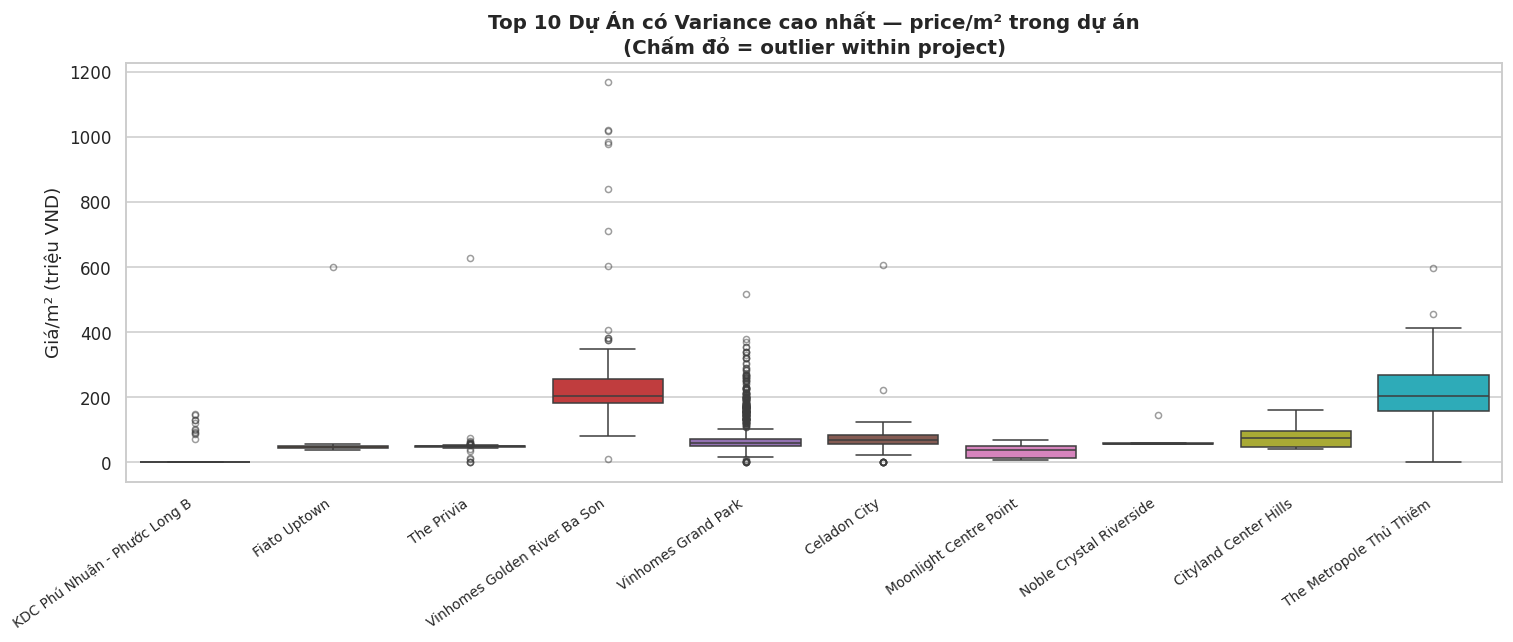

In [ ]:
# ============================================================
# CELL 3B: Project-level Outlier — variance & abnormal listings
# ============================================================
proj_stats = df.groupby('project_name')['price_m2'].agg(
    count='count', mean='mean', median='median',
    std='std', cv=lambda x: x.std()/x.mean() if x.mean()>0 else 0,
    p5=lambda x: x.quantile(0.05), p95=lambda x: x.quantile(0.95)
).reset_index()
proj_stats['range_ratio'] = proj_stats['p95'] / (proj_stats['p5'] + 1e-6)
proj_stats = proj_stats[proj_stats['count'] >= 5].sort_values('cv', ascending=False)

print('TOP 15 DỰ ÁN CÓ VARIANCE CAO NHẤT (price/m²):')
display(
    proj_stats.head(15)
    .round(2)
    .style
    .background_gradient(subset=['cv'], cmap='Reds')
    .background_gradient(subset=['range_ratio'], cmap='Oranges')
)

# Detect abnormal listings: price_m2 > mean + 3*std trong cùng project
df_tmp = df.copy()
proj_mu_sigma = df.groupby('project_name')['price_m2'].agg(['mean','std']).reset_index()
df_tmp = df_tmp.merge(proj_mu_sigma, on='project_name', how='left')
df_tmp['z_within_project'] = (df_tmp['price_m2'] - df_tmp['mean']) / (df_tmp['std'] + 1e-6)
abnormal = df_tmp[df_tmp['z_within_project'].abs() > 3][['project_name','price_m2','area_m2','bedrooms','z_within_project']]
print(f'\nSố listing bất thường trong dự án (|z|>3): {len(abnormal)}')
display(abnormal.sort_values('z_within_project', ascending=False).head(10).round(2))

# Visualize: top 10 projects có variance cao
top10_proj = proj_stats.head(10)['project_name'].tolist()
df_plot = df[df['project_name'].isin(top10_proj)]

fig, ax = plt.subplots(figsize=(14, 6))
order = proj_stats.head(10)['project_name']
sns.boxplot(data=df_plot, x='project_name', y='price_m2', order=order, ax=ax,
            palette='tab10',
            flierprops=dict(marker='o', alpha=0.5, markersize=4, color='red'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_title('Top 10 Dự Án có Variance cao nhất — price/m² trong dự án\n(Chấm đỏ = outlier within project)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Giá/m² (triệu VND)')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FULL Project-level Outlier Listings
# ============================================================

df_proj = df.copy()

# Mean + std theo project
proj_stats_full = (
    df_proj.groupby('project_name')['price_m2']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

df_proj = df_proj.merge(proj_stats_full, on='project_name', how='left')

# Z-score within project
df_proj['z_project'] = (
    (df_proj['price_m2'] - df_proj['mean']) /
    (df_proj['std'] + 1e-6)
)

# Full outlier table
project_outliers = df_proj[
    df_proj['z_project'].abs() > 3
].sort_values(
    'z_project',
    ascending=False
)

cols_show = [
    'project_name',
    'project_type',
    'price_m2',
    'area_m2',
    'bedrooms',
    'bathrooms',
    'z_project'
]

display(project_outliers[cols_show].round(2))

print(f'Tổng số project-level outlier: {len(project_outliers)}')

,project_name,project_type,price_m2,area_m2,bedrooms,bathrooms,z_project
2808,Celadon City,Khu phức hợp,607.14,84.0,3,2,12.59
3268,Vinhomes Grand Park,Khu phức hợp,517.54,570.0,4,8,9.15
5885,The Privia,Căn hộ chung cư,628.57,35.0,3,1,8.68
4617,Fiato Uptown,Căn hộ chung cư,600.00,80.0,3,2,6.99
4743,Chung cư MT Eastmark City,Căn hộ chung cư,117.59,97.8,1,3,6.53
...,...,...,...,...,...,...,...
4539,Paris Hoàng Kim,Căn hộ chung cư,19.54,87.0,3,2,-4.82
4540,Paris Hoàng Kim,Căn hộ chung cư,0.23,70.0,2,2,-5.98
1225,Diamond Centery,Căn hộ chung cư,26.00,160.0,3,3,-5.98
1215,Diamond Centery,Căn hộ chung cư,22.92,96.0,3,2,-6.29


Tổng số project-level outlier: 148


### Cell 3C — Property-Type Outlier: Phân tích theo loại BĐS

Phân phối project_type:
project_type
Căn hộ chung cư     3192
Khu phức hợp        2357
Khu đô thị mới       811
Shophouse             39
Biệt thự liền kề      20
Dự án khác            14
Nhà mặt phố            2
Name: count, dtype: int64


,Type,Count,Median_price_m2,Std,IQR_outliers,Out_%
4,Shophouse,39,173.800000,20.700000,10,25.6%
2,Dự án khác,14,107.300000,38.900000,1,7.1%
5,Biệt thự liền kề,20,73.600000,54.000000,1,5.0%
0,Căn hộ chung cư,3192,63.000000,108.900000,419,13.1%
1,Khu đô thị mới,811,63.000000,103.200000,118,14.5%
3,Khu phức hợp,2357,61.500000,87.100000,417,17.7%


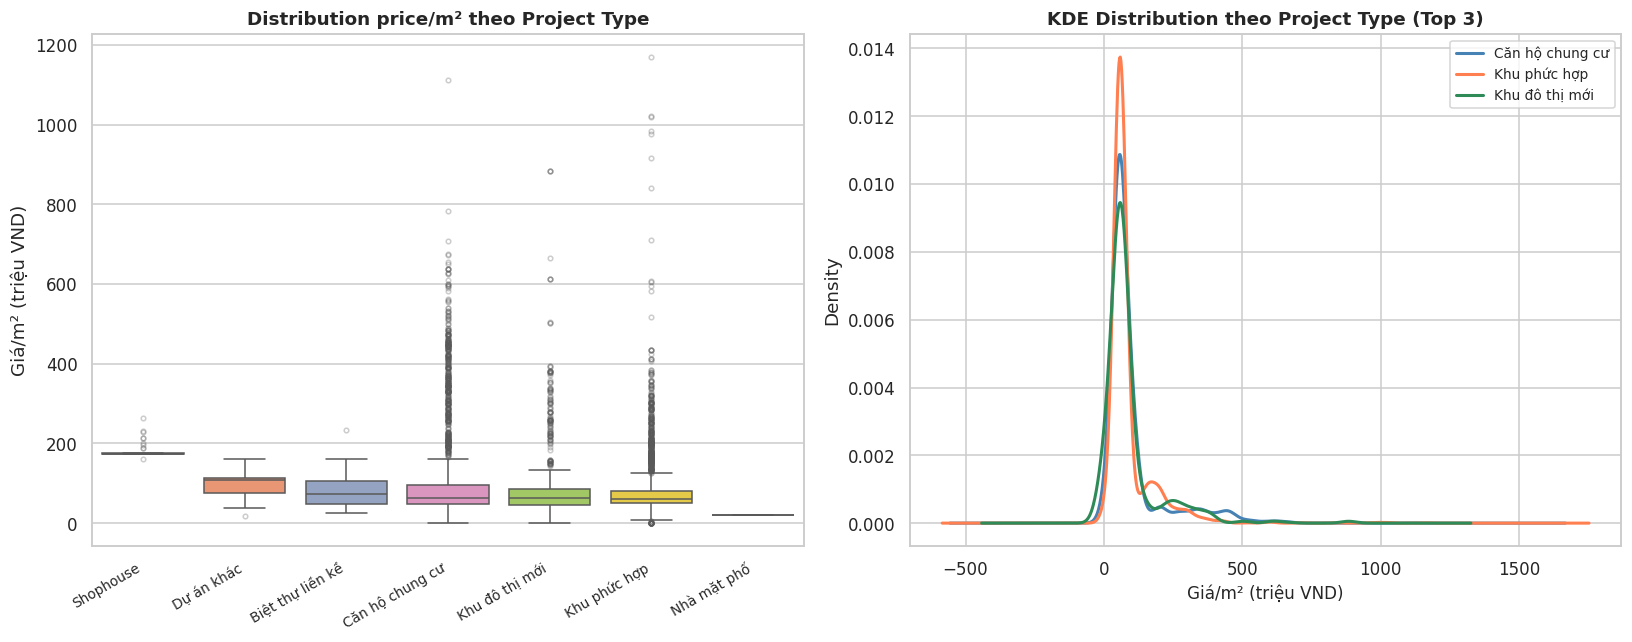

In [ ]:
# ============================================================
# CELL 3C: Property-Type Outlier & Distribution
# ============================================================
print('Phân phối project_type:')
print(df['project_type'].value_counts())

# Outlier theo từng loại
type_outlier = []
for ptype in df['project_type'].dropna().unique():
    sub = df[df['project_type'] == ptype]['price_m2'].dropna()
    if len(sub) < 5: continue
    Q1, Q3 = sub.quantile(0.25), sub.quantile(0.75)
    IQR = Q3 - Q1
    out = ((sub < Q1-1.5*IQR) | (sub > Q3+1.5*IQR)).sum()
    type_outlier.append({
        'Type': ptype, 'Count': len(sub),
        'Median_price_m2': sub.median(), 'Std': sub.std(),
        'IQR_outliers': out, 'Out_%': out / len(sub) * 100
    })
type_df = (
    pd.DataFrame(type_outlier)
    .sort_values('Median_price_m2', ascending=False)
    .round(1)
)

display(
    type_df.style
    .background_gradient(subset=['Median_price_m2'], cmap='Blues')
    .background_gradient(subset=['Out_%'], cmap='Reds')
    .format({'Out_%': '{:.1f}%'})
)

# Boxplot so sánh distribution theo loại
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order = df.groupby('project_type')['price_m2'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='project_type', y='price_m2', order=order, ax=axes[0],
            palette='Set2', flierprops=dict(marker='o', alpha=0.3, markersize=3))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=9)
axes[0].set_title('Distribution price/m² theo Project Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Giá/m² (triệu VND)')

# KDE per type (top 3)
top3 = ['Căn hộ chung cư', 'Khu phức hợp', 'Khu đô thị mới']
colors_kde = ['steelblue', 'coral', 'seagreen']
for ptype, color in zip(top3, colors_kde):
    sub = df[df['project_type'] == ptype]['price_m2'].dropna()
    sub.plot(kind='kde', ax=axes[1], color=color, lw=2, label=ptype)
axes[1].set_xlabel('Giá/m² (triệu VND)', fontsize=11)
axes[1].set_title('KDE Distribution theo Project Type (Top 3)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FULL Property-Type Outlier Listings
# ============================================================

all_type_outliers = []

for ptype in df['project_type'].dropna().unique():

    sub = df[df['project_type'] == ptype].copy()

    if len(sub) < 5:
        continue

    Q1 = sub['price_m2'].quantile(0.25)
    Q3 = sub['price_m2'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = sub[
        (sub['price_m2'] < lower) |
        (sub['price_m2'] > upper)
    ].copy()

    outliers['lower_bound'] = lower
    outliers['upper_bound'] = upper

    all_type_outliers.append(outliers)

type_outlier_df = pd.concat(all_type_outliers)

cols_show = [
    'project_type',
    'project_name',
    'price_m2',
    'area_m2',
    'bedrooms'
]

display(type_outlier_df[cols_show])

print(f'Tổng số type-level outlier: {len(type_outlier_df)}')

,project_type,project_name,price_m2,area_m2,bedrooms
78,Căn hộ chung cư,The Grand Manhattan,194.366197,71.0,2
79,Căn hộ chung cư,The Grand Manhattan,208.247423,97.0,2
80,Căn hộ chung cư,The Grand Manhattan,193.507504,96.2,3
81,Căn hộ chung cư,The Grand Manhattan,189.528024,67.8,2
82,Căn hộ chung cư,The Grand Manhattan,198.529412,68.0,2
...,...,...,...,...,...
5245,Shophouse,The Sholi Bình Tân,227.868852,61.0,4
5251,Shophouse,The Sholi Bình Tân,187.500000,64.0,4
5257,Shophouse,The Sholi Bình Tân,187.500000,64.0,4
5259,Shophouse,The Sholi Bình Tân,161.250000,80.0,4


Tổng số type-level outlier: 966


### Cell 3D — Outlier Strategy Summary: Giữ hay Bỏ?

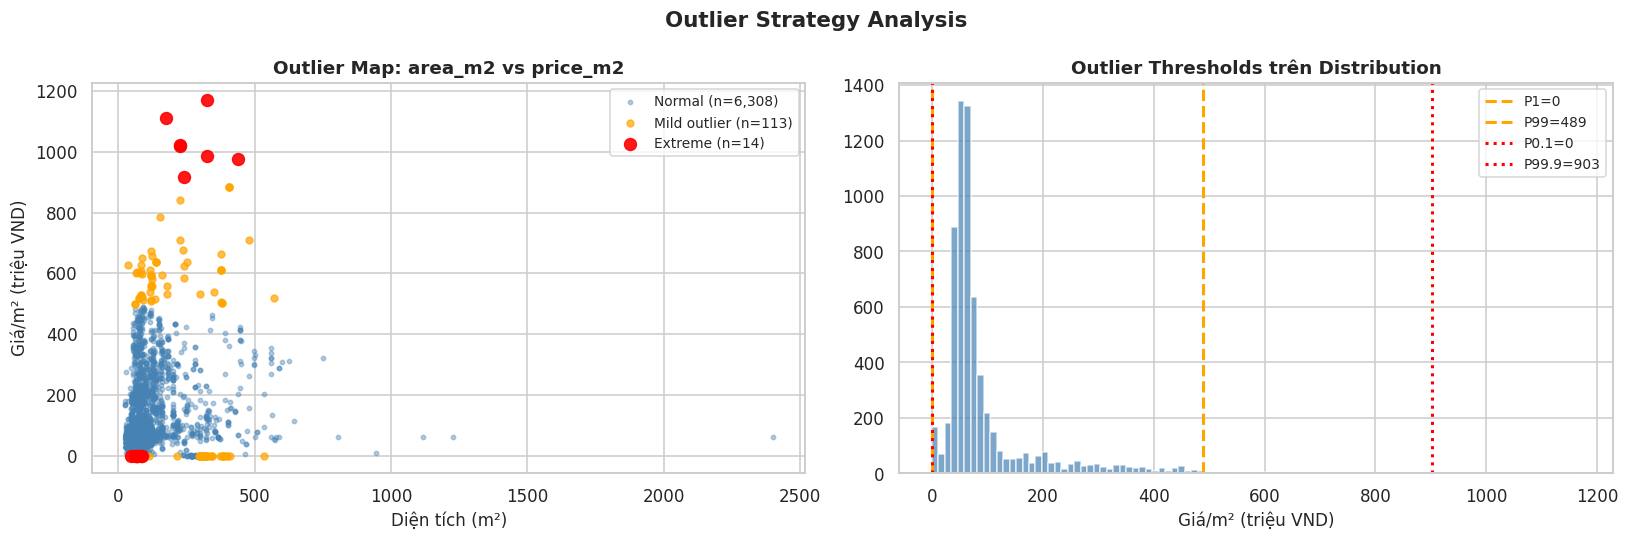

TOP Extreme Outlier (giá cao nhất):


,project_name,project_type,area_m2,price_m2,bedrooms
2137,Vinhomes Golden River Ba Son,Khu phức hợp,325.0,1169.230769,6
1487,The Opera Residence,Căn hộ chung cư,174.8,1112.128146,2
2160,Vinhomes Golden River Ba Son,Khu phức hợp,225.0,1022.222222,2
2144,Vinhomes Golden River Ba Son,Khu phức hợp,225.0,1017.777778,6
2151,Vinhomes Golden River Ba Son,Khu phức hợp,325.0,984.615385,6
2152,Vinhomes Golden River Ba Son,Khu phức hợp,438.0,977.168950,6
422,Saigon Mystery Villas,Khu phức hợp,240.0,916.666667,4



TOP Extreme Outlier (giá thấp nhất):


,project_name,project_type,area_m2,price_m2,bedrooms
5573,Diyas Sky,Căn hộ chung cư,60.0,0.019167,2
5042,Vinhomes Grand Park,Khu phức hợp,69.0,0.029348,2
4851,Q7 Saigon Riverside,Căn hộ chung cư,68.0,0.039706,2
4813,Q7 Saigon Riverside,Căn hộ chung cư,67.0,0.045970,2
4809,Q7 Saigon Riverside,Căn hộ chung cư,86.0,0.053488,2
5263,The Privia,Căn hộ chung cư,83.0,0.059639,3
4284,Khải Hoàn Prime,Căn hộ chung cư,48.0,0.060417,2


In [ ]:
# ============================================================
# CELL 3D: Outlier Strategy — Phân tích & Đề xuất
# ============================================================
target = df['price_m2'].dropna()

# Phân tầng outlier
p01, p99 = target.quantile(0.01), target.quantile(0.99)
p001, p999 = target.quantile(0.001), target.quantile(0.999)

extreme = df[df['price_m2'] > p999][['project_name','project_type','area_m2','price_m2','bedrooms']].sort_values('price_m2', ascending=False)
low_extreme = df[df['price_m2'] < p001][['project_name','project_type','area_m2','price_m2','bedrooms']].sort_values('price_m2')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: area vs price_m2 với màu theo outlier type
normal  = df[(df['price_m2'] >= p01) & (df['price_m2'] <= p99)]
mild    = df[((df['price_m2'] < p01) | (df['price_m2'] > p99)) &
             ((df['price_m2'] >= p001) & (df['price_m2'] <= p999))]
extreme_df = df[(df['price_m2'] < p001) | (df['price_m2'] > p999)]

axes[0].scatter(normal['area_m2'], normal['price_m2'],   s=8,  alpha=0.4, color='steelblue', label=f'Normal (n={len(normal):,})')
axes[0].scatter(mild['area_m2'],   mild['price_m2'],     s=20, alpha=0.7, color='orange',    label=f'Mild outlier (n={len(mild):,})')
axes[0].scatter(extreme_df['area_m2'], extreme_df['price_m2'], s=60, alpha=0.9, color='red', label=f'Extreme (n={len(extreme_df):,})')
axes[0].set_xlabel('Diện tích (m²)', fontsize=11)
axes[0].set_ylabel('Giá/m² (triệu VND)', fontsize=11)
axes[0].set_title('Outlier Map: area_m2 vs price_m2', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Histogram với annotation
axes[1].hist(target, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(p01,  color='orange', ls='--', lw=2, label=f'P1={p01:.0f}')
axes[1].axvline(p99,  color='orange', ls='--', lw=2, label=f'P99={p99:.0f}')
axes[1].axvline(p001, color='red',    ls=':',  lw=2, label=f'P0.1={p001:.0f}')
axes[1].axvline(p999, color='red',    ls=':',  lw=2, label=f'P99.9={p999:.0f}')
axes[1].set_xlabel('Giá/m² (triệu VND)', fontsize=11)
axes[1].set_title('Outlier Thresholds trên Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Outlier Strategy Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('TOP Extreme Outlier (giá cao nhất):')
display(extreme)
print('\nTOP Extreme Outlier (giá thấp nhất):')
display(low_extreme)

In [ ]:
# ============================================================
# FULL OUTLIER AUDIT TABLE
# ============================================================

import pandas as pd
import numpy as np

df_out = df.copy()

# ============================================================
# 1. GLOBAL OUTLIER (price_m2)
# ============================================================

Q1 = df_out['price_m2'].quantile(0.25)
Q3 = df_out['price_m2'].quantile(0.75)
IQR = Q3 - Q1

global_lower = Q1 - 1.5 * IQR
global_upper = Q3 + 1.5 * IQR

df_out['global_outlier'] = (
    (df_out['price_m2'] < global_lower) |
    (df_out['price_m2'] > global_upper)
)

# ============================================================
# 2. PROJECT-LEVEL OUTLIER
# ============================================================

proj_stats = (
    df_out.groupby('project_name')['price_m2']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

df_out = df_out.merge(
    proj_stats,
    on='project_name',
    how='left'
)

df_out['z_project'] = (
    (df_out['price_m2'] - df_out['mean']) /
    (df_out['std'] + 1e-6)
)

df_out['project_outlier'] = (
    df_out['z_project'].abs() > 3
)

# ============================================================
# 3. PROPERTY-TYPE OUTLIER
# ============================================================

df_out['type_outlier'] = False

for ptype in df_out['project_type'].dropna().unique():

    sub_idx = df_out['project_type'] == ptype

    sub = df_out.loc[sub_idx, 'price_m2']

    if len(sub) < 5:
        continue

    q1 = sub.quantile(0.25)
    q3 = sub.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (
        (df_out['project_type'] == ptype) &
        (
            (df_out['price_m2'] < lower) |
            (df_out['price_m2'] > upper)
        )
    )

    df_out.loc[mask, 'type_outlier'] = True

# ============================================================
# 4. COMBINE REASONS
# ============================================================

df_out['outlier_reason'] = ''

df_out.loc[
    df_out['global_outlier'],
    'outlier_reason'
] += 'GLOBAL_IQR; '

df_out.loc[
    df_out['project_outlier'],
    'outlier_reason'
] += 'PROJECT_ZSCORE; '

df_out.loc[
    df_out['type_outlier'],
    'outlier_reason'
] += 'TYPE_IQR; '

# ============================================================
# 5. FINAL OUTLIER TABLE
# ============================================================

candidate_outliers = df_out[
    (
        df_out['global_outlier'] |
        df_out['project_outlier'] |
        df_out['type_outlier']
    )
].copy()

# ============================================================
# 6. SORT
# ============================================================

candidate_outliers = candidate_outliers.sort_values(
    ['project_outlier', 'type_outlier', 'price_m2'],
    ascending=[False, False, False]
)

# ============================================================
# 7. DISPLAY
# ============================================================

cols_show = [
    'project_name',
    'project_type',
    'price_m2',
    'area_m2',
    'bedrooms',
    'bathrooms',
    'outlier_reason',
    'z_project'
]

display(candidate_outliers[cols_show].round(2))

print(f'Tổng số candidate outlier: {len(candidate_outliers)}')

,project_name,project_type,price_m2,area_m2,bedrooms,bathrooms,outlier_reason,z_project
2137,Vinhomes Golden River Ba Son,Khu phức hợp,1169.23,325.00,6,6,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;,5.16
1487,The Opera Residence,Căn hộ chung cư,1112.13,174.80,2,2,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;,5.24
2160,Vinhomes Golden River Ba Son,Khu phức hợp,1022.22,225.00,2,2,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;,4.33
2144,Vinhomes Golden River Ba Son,Khu phức hợp,1017.78,225.00,6,6,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;,4.30
2151,Vinhomes Golden River Ba Son,Khu phức hợp,984.62,325.00,6,8,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;,4.11
...,...,...,...,...,...,...,...,...
5550,The Metropole Thủ Thiêm,Căn hộ chung cư,150.00,90.00,4,1,GLOBAL_IQR;,-0.63
523,Zenity,Căn hộ chung cư,149.35,154.00,3,3,GLOBAL_IQR;,0.79
2097,Khu dân cư Hồng Long,Dự án khác,149.12,57.00,4,5,GLOBAL_IQR;,1.36
1337,Cardinal Court,Căn hộ chung cư,148.81,100.80,3,2,GLOBAL_IQR;,0.35


Tổng số candidate outlier: 1076


In [ ]:
# ============================================================
# OUTLIER REASON SUMMARY
# ============================================================

reason_summary = (
    candidate_outliers['outlier_reason']
    .value_counts()
    .reset_index()
)

reason_summary.columns = ['reason', 'count']

display(reason_summary)

,reason,count
0,GLOBAL_IQR; TYPE_IQR;,821
1,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;,79
2,PROJECT_ZSCORE;,67
3,TYPE_IQR;,64
4,GLOBAL_IQR;,43
5,PROJECT_ZSCORE; TYPE_IQR;,2


In [ ]:
# ============================================================
# PROJECT-LEVEL SUSPICIOUS OUTLIERS
# ============================================================

project_suspicious = candidate_outliers[
    candidate_outliers['outlier_reason']
    .str.contains('PROJECT_ZSCORE')
].copy()

display(
    project_suspicious[
        [
            'project_name',
            'project_type',
            'price_m2',
            'area_m2',
            'bedrooms',
            'bathrooms',
            'z_project',
            'outlier_reason'
        ]
    ]
    .sort_values('z_project', ascending=False)
    .round(2)
)

print(f'Tổng PROJECT_ZSCORE outlier: {len(project_suspicious)}')

,project_name,project_type,price_m2,area_m2,bedrooms,bathrooms,z_project,outlier_reason
2808,Celadon City,Khu phức hợp,607.14,84.0,3,2,12.59,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;
3268,Vinhomes Grand Park,Khu phức hợp,517.54,570.0,4,8,9.15,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;
5885,The Privia,Căn hộ chung cư,628.57,35.0,3,1,8.68,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;
4617,Fiato Uptown,Căn hộ chung cư,600.00,80.0,3,2,6.99,GLOBAL_IQR; PROJECT_ZSCORE; TYPE_IQR;
4743,Chung cư MT Eastmark City,Căn hộ chung cư,117.59,97.8,1,3,6.53,PROJECT_ZSCORE;
...,...,...,...,...,...,...,...,...
4539,Paris Hoàng Kim,Căn hộ chung cư,19.54,87.0,3,2,-4.82,PROJECT_ZSCORE;
4540,Paris Hoàng Kim,Căn hộ chung cư,0.23,70.0,2,2,-5.98,PROJECT_ZSCORE;
1225,Diamond Centery,Căn hộ chung cư,26.00,160.0,3,3,-5.98,PROJECT_ZSCORE;
1215,Diamond Centery,Căn hộ chung cư,22.92,96.0,3,2,-6.29,PROJECT_ZSCORE;


Tổng PROJECT_ZSCORE outlier: 148


In [ ]:
# ============================================================
# MOST ABNORMAL WITHIN PROJECT
# ============================================================

very_suspicious = project_suspicious[
    project_suspicious['z_project'].abs() > 5
]

display(
    very_suspicious[
        [
            'project_name',
            'project_type',
            'price_m2',
            'area_m2',
            'bedrooms',
            'bathrooms',
            'z_project'
        ]
    ]
    .sort_values('z_project', ascending=False)
    .round(2)
)

print(f'Very suspicious listings: {len(very_suspicious)}')

,project_name,project_type,price_m2,area_m2,bedrooms,bathrooms,z_project
2808,Celadon City,Khu phức hợp,607.14,84.0,3,2,12.59
3268,Vinhomes Grand Park,Khu phức hợp,517.54,570.0,4,8,9.15
5885,The Privia,Căn hộ chung cư,628.57,35.0,3,1,8.68
4617,Fiato Uptown,Căn hộ chung cư,600.00,80.0,3,2,6.99
4743,Chung cư MT Eastmark City,Căn hộ chung cư,117.59,97.8,1,3,6.53
3179,Vinhomes Grand Park,Khu phức hợp,377.78,90.0,5,5,6.27
3135,Vinhomes Grand Park,Khu phức hợp,370.83,240.0,2,2,6.13
3036,Vinhomes Grand Park,Khu phức hợp,355.36,560.0,4,8,5.81
3829,Vinhomes Grand Park,Khu phức hợp,354.17,240.0,4,4,5.79
4249,Vinhomes Grand Park,Khu phức hợp,340.61,229.0,2,2,5.51


Very suspicious listings: 26


In [ ]:
# ============================================================
# FINAL REMOVE CANDIDATES
# ============================================================

remove_candidates = project_suspicious[
    (
        project_suspicious['price_m2'] < 5
    )
    |
    (
        (project_suspicious['area_m2'] < 50) &
        (project_suspicious['bedrooms'] >= 3)
    )
    |
    (
        (project_suspicious['z_project'].abs() > 7) &
        (project_suspicious['price_m2'] > 500)
    )
].copy()

display(
    remove_candidates[
        [
            'project_name',
            'project_type',
            'price_m2',
            'area_m2',
            'bedrooms',
            'bathrooms',
            'z_project'
        ]
    ]
    .sort_values('z_project', ascending=False)
    .round(2)
)

print(f'Total REMOVE candidates: {len(remove_candidates)}')

,project_name,project_type,price_m2,area_m2,bedrooms,bathrooms,z_project
2808,Celadon City,Khu phức hợp,607.14,84.0,3,2,12.59
3268,Vinhomes Grand Park,Khu phức hợp,517.54,570.0,4,8,9.15
5885,The Privia,Căn hộ chung cư,628.57,35.0,3,1,8.68
4284,Khải Hoàn Prime,Căn hộ chung cư,0.06,48.0,2,2,-3.07
5987,Zenity,Căn hộ chung cư,1.76,85.0,2,2,-3.09
4704,Grand Marina Saigon,Căn hộ chung cư,0.43,55.0,1,1,-3.10
5433,Kingdom 101,Căn hộ chung cư,0.27,78.0,2,2,-3.69
5477,Kingdom 101,Căn hộ chung cư,0.23,75.0,2,2,-3.70
5438,Kingdom 101,Căn hộ chung cư,0.08,60.0,1,1,-3.70
6109,Chung cư MT Eastmark City,Căn hộ chung cư,4.85,130.0,1,1,-3.71


Total REMOVE candidates: 28


---
## SECTION 4 — PROJECT-LEVEL ANALYSIS

### Cell 4A — Project Effect: Variance & Listing Count

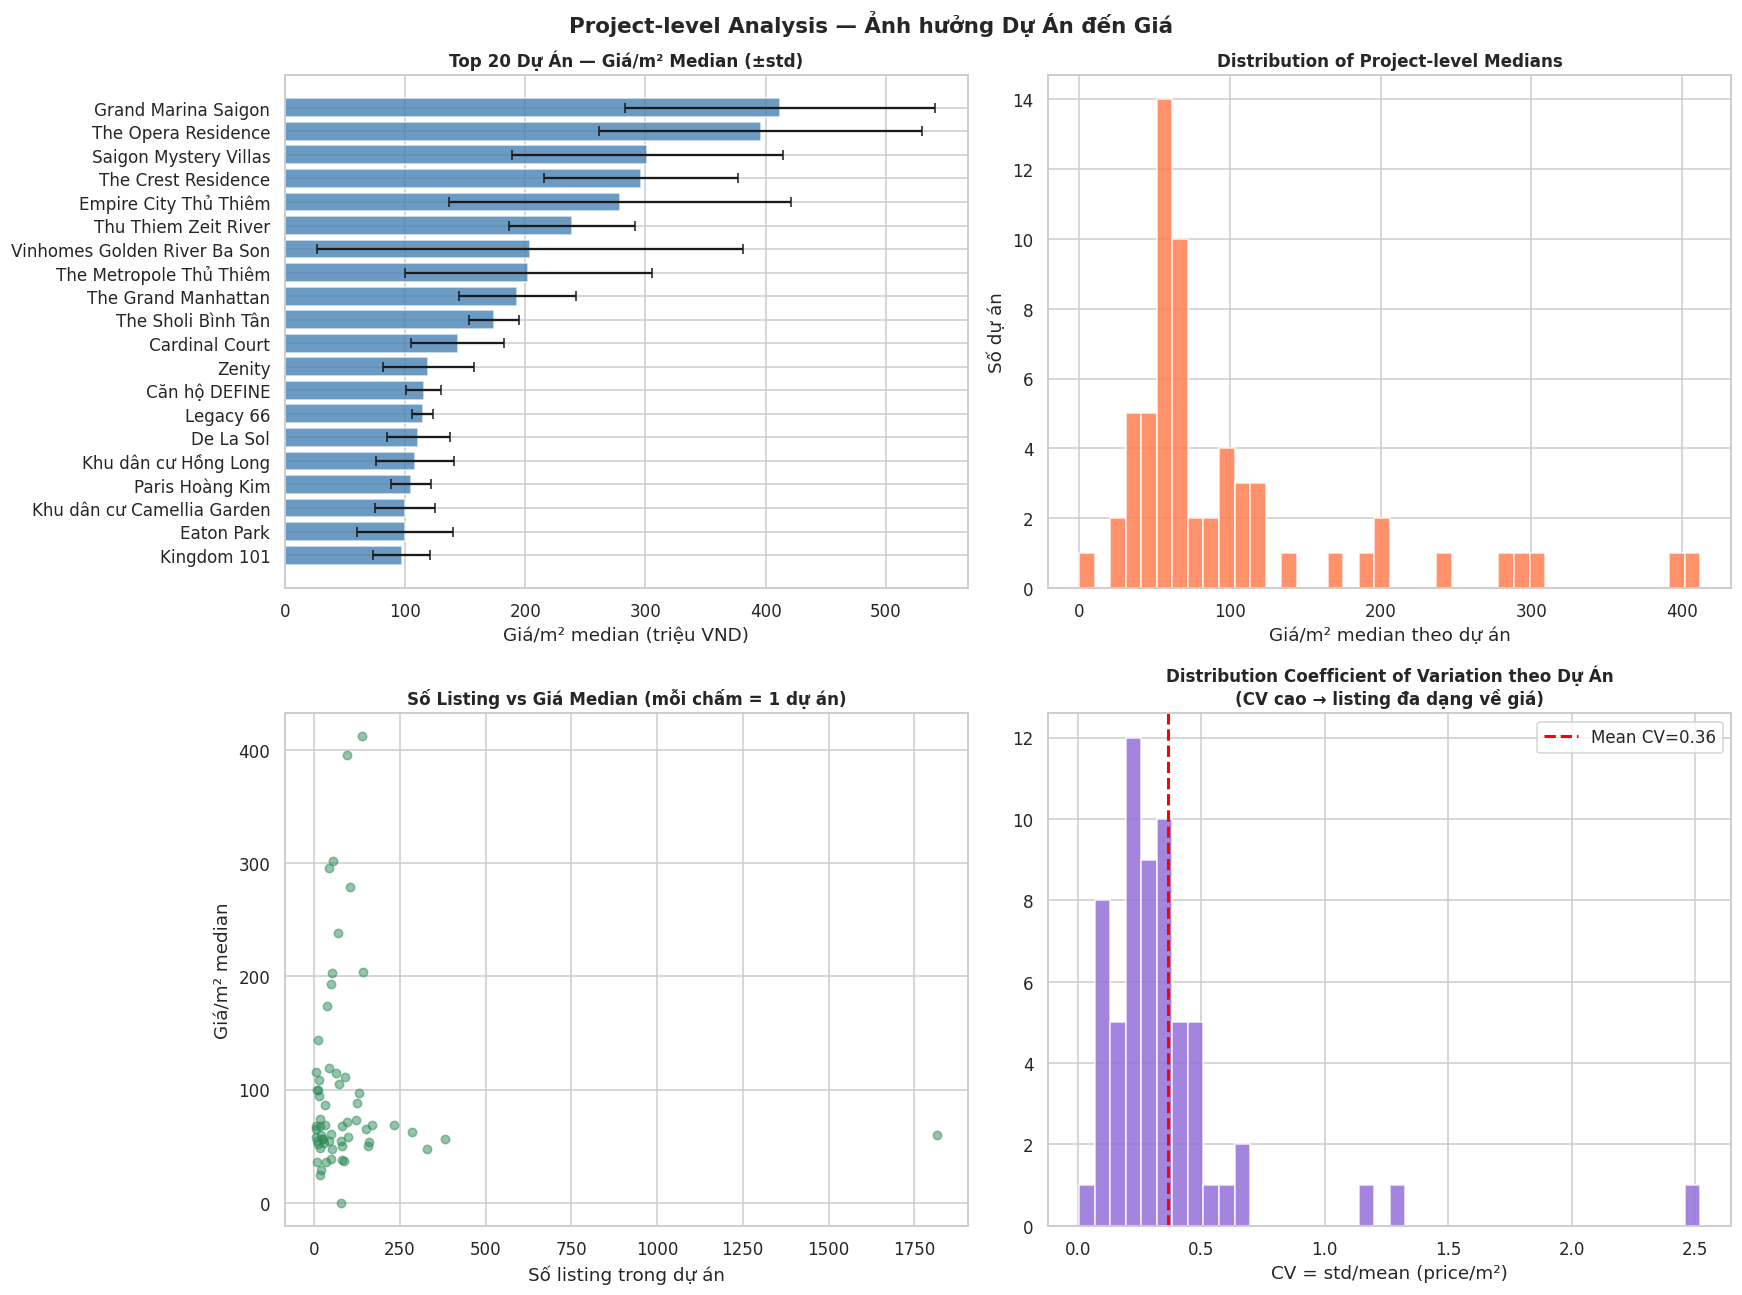


ANOVA — project_name effect: F=253.1, p=0.00e+00
→ project_name có ảnh hưởng cực kỳ có ý nghĩa đến giá


In [ ]:
# ============================================================
# CELL 4A: Project-level Analysis — avg, variance, count
# ============================================================
proj_agg = df.groupby('project_name')['price_m2'].agg(
    n='count', mean='mean', median='median', std='std',
    p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
).reset_index()
proj_agg['cv'] = proj_agg['std'] / proj_agg['mean']
proj_agg = proj_agg[proj_agg['n'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 20 dự án theo giá median
top20 = proj_agg.head(20)
axes[0,0].barh(top20['project_name'][::-1], top20['median'][::-1],
               xerr=top20['std'][::-1], color='steelblue', alpha=0.8, capsize=3)
axes[0,0].set_xlabel('Giá/m² median (triệu VND)')
axes[0,0].set_title('Top 20 Dự Án — Giá/m² Median (±std)', fontsize=11, fontweight='bold')

# Distribution of project medians
axes[0,1].hist(proj_agg['median'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].set_xlabel('Giá/m² median theo dự án')
axes[0,1].set_title('Distribution of Project-level Medians', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Số dự án')

# Số listing vs giá median
axes[1,0].scatter(proj_agg['n'], proj_agg['median'], alpha=0.5, s=30, color='seagreen')
axes[1,0].set_xlabel('Số listing trong dự án')
axes[1,0].set_ylabel('Giá/m² median')
axes[1,0].set_title('Số Listing vs Giá Median (mỗi chấm = 1 dự án)', fontsize=11, fontweight='bold')

# CV (Coefficient of Variation) của từng dự án
cv_dist = proj_agg['cv'].dropna()
axes[1,1].hist(cv_dist, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1,1].axvline(cv_dist.mean(), color='red', ls='--', lw=2, label=f'Mean CV={cv_dist.mean():.2f}')
axes[1,1].set_xlabel('CV = std/mean (price/m²)')
axes[1,1].set_title('Distribution Coefficient of Variation theo Dự Án\n(CV cao → listing đa dạng về giá)', fontsize=11, fontweight='bold')
axes[1,1].legend()

plt.suptitle('Project-level Analysis — Ảnh hưởng Dự Án đến Giá', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ANOVA test: project_name có significant effect không?
groups = [grp['price_m2'].dropna().values for _, grp in df.groupby('project_name') if len(grp) >= 5]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nANOVA — project_name effect: F={f_stat:.1f}, p={p_val:.2e}')
print(f'→ {"project_name có ảnh hưởng cực kỳ có ý nghĩa đến giá" if p_val < 0.001 else "❌ Không có ý nghĩa"}')

### Cell 4B — Target Encoding Preview: Project Mean/Median

---



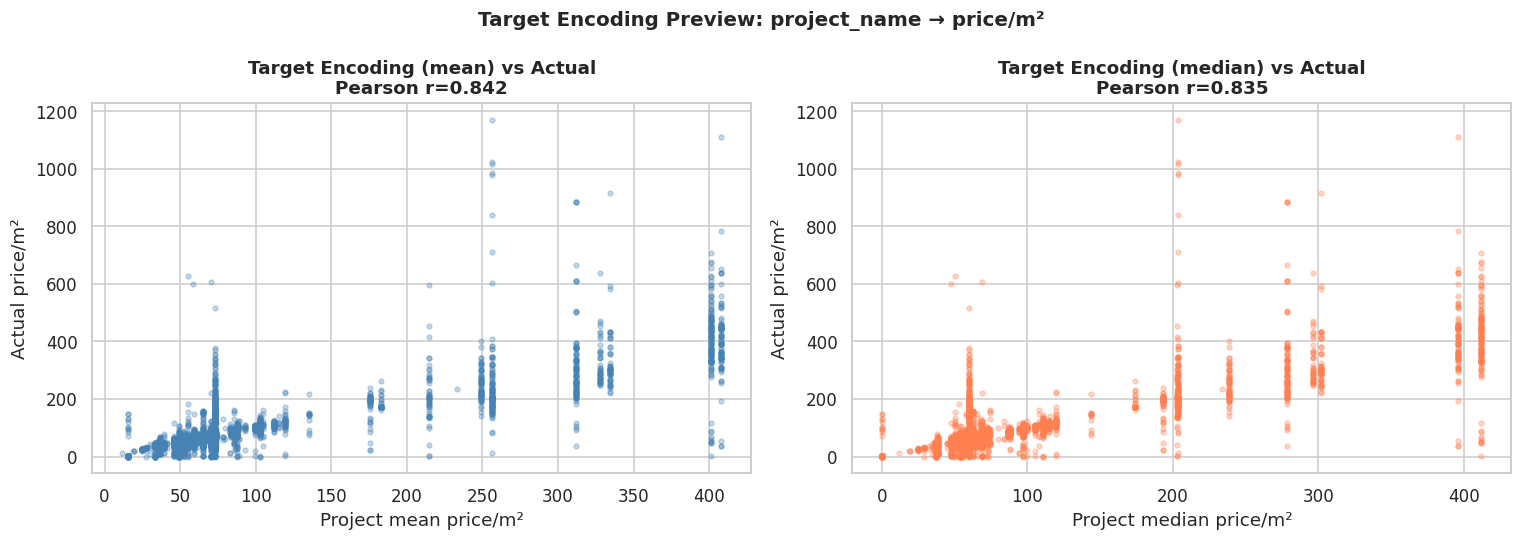

Project-level Target Encoding Correlation:
  - Mean encoding:   r = 0.842
  - Median encoding: r = 0.835
  → Median encoding robust hơn với outlier → ưu tiên dùng
  → CẢNH BÁO: dùng cross-validation khi tính target encoding để tránh data leak!


In [ ]:
# ============================================================
# CELL 4B: Target Encoding Preview — project_name
# ============================================================
# Simulate target encoding
project_te = df.groupby('project_name')['price_m2'].agg(
    proj_mean='mean', proj_median='median', proj_std='std', proj_count='count'
).reset_index()
df_te = df.merge(project_te, on='project_name', how='left')

# Correlation giữa target encoding và actual price
r_mean,   _ = stats.pearsonr(df_te['proj_mean'].dropna(), df_te['price_m2'][df_te['proj_mean'].notna()])
r_median, _ = stats.pearsonr(df_te['proj_median'].dropna(), df_te['price_m2'][df_te['proj_median'].notna()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_te['proj_mean'], df_te['price_m2'], alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Project mean price/m²')
axes[0].set_ylabel('Actual price/m²')
axes[0].set_title(f'Target Encoding (mean) vs Actual\nPearson r={r_mean:.3f}', fontsize=12, fontweight='bold')

axes[1].scatter(df_te['proj_median'], df_te['price_m2'], alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Project median price/m²')
axes[1].set_ylabel('Actual price/m²')
axes[1].set_title(f'Target Encoding (median) vs Actual\nPearson r={r_median:.3f}', fontsize=12, fontweight='bold')

plt.suptitle('Target Encoding Preview: project_name → price/m²', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Project-level Target Encoding Correlation:')
print(f'  - Mean encoding:   r = {r_mean:.3f}')
print(f'  - Median encoding: r = {r_median:.3f}')
print(f'  → Median encoding robust hơn với outlier → ưu tiên dùng')
print(f'  → CẢNH BÁO: dùng cross-validation khi tính target encoding để tránh data leak!')

---
## SECTION 5 — PROPERTY TYPE ANALYSIS

### Cell 5A — Distribution Comparison theo Property Type

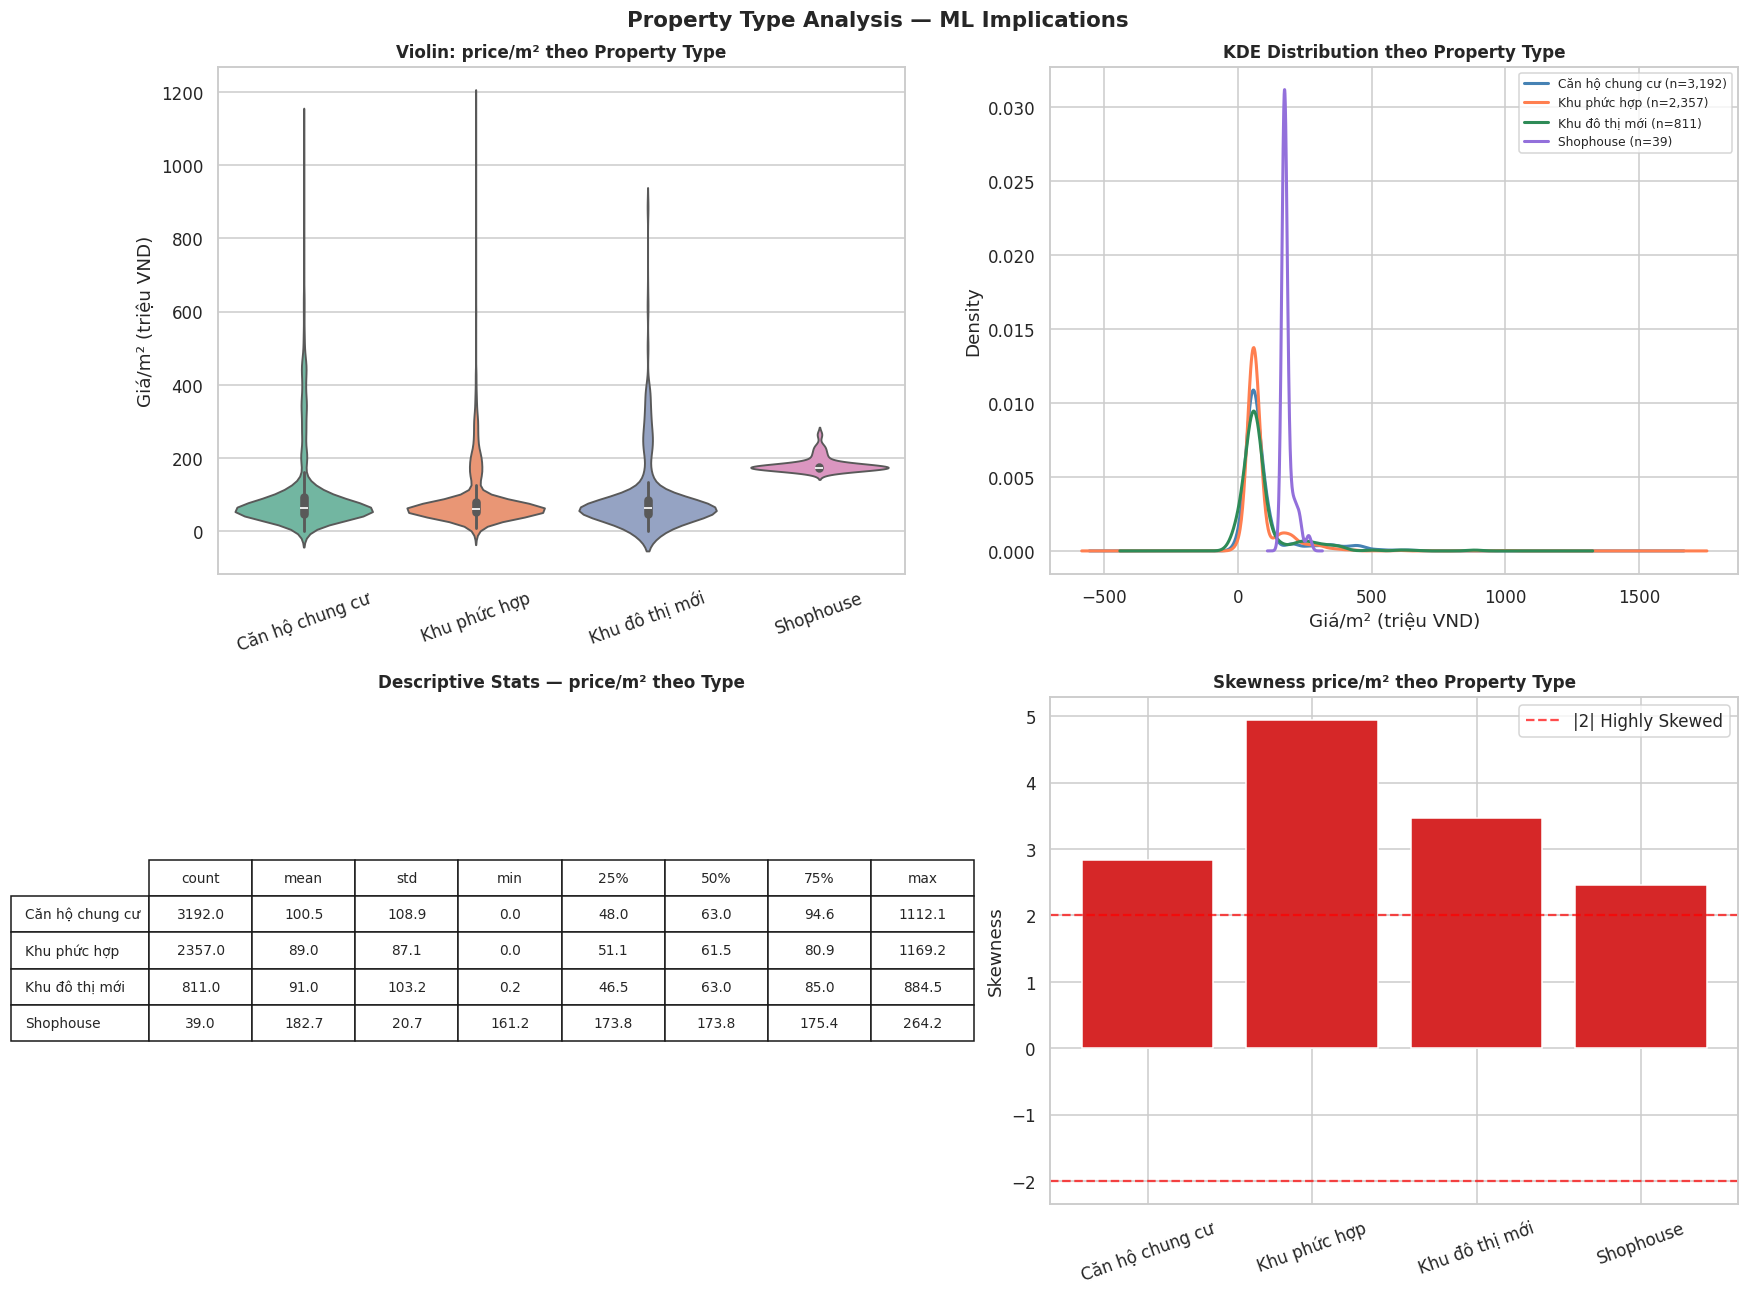

Kruskal-Wallis test: H=74.0, p=6.06e-16
→ Distribution khác nhau significant giữa các loại BĐS


In [ ]:
# ============================================================
# CELL 5A: Property Type — Distribution & ML Implications
# ============================================================
type_order = df.groupby('project_type')['price_m2'].median().sort_values(ascending=False).index.tolist()
main_types = ['Căn hộ chung cư', 'Khu phức hợp', 'Khu đô thị mới', 'Shophouse']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Violin plot
sns.violinplot(data=df[df['project_type'].isin(main_types)],
               x='project_type', y='price_m2', ax=axes[0,0],
               palette='Set2', inner='box', order=main_types)
axes[0,0].set_title('Violin: price/m² theo Property Type', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Giá/m² (triệu VND)')
axes[0,0].tick_params(axis='x', rotation=20)

# 2. KDE overlay
colors = ['steelblue','coral','seagreen','mediumpurple']
for ptype, color in zip(main_types, colors):
    sub = df[df['project_type']==ptype]['price_m2'].dropna()
    if len(sub) >= 10:
        sub.plot(kind='kde', ax=axes[0,1], color=color, lw=2,
                 label=f'{ptype} (n={len(sub):,})')
axes[0,1].set_xlabel('Giá/m² (triệu VND)')
axes[0,1].set_title('KDE Distribution theo Property Type', fontsize=11, fontweight='bold')
axes[0,1].legend(fontsize=8)

# 3. Descriptive stats table visualized
type_stats = df[df['project_type'].isin(main_types)].groupby('project_type')['price_m2'].describe().round(1)
axes[1,0].axis('off')
tbl = axes[1,0].table(
    cellText=type_stats.values,
    rowLabels=type_stats.index,
    colLabels=type_stats.columns,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
axes[1,0].set_title('Descriptive Stats — price/m² theo Type', fontsize=11, fontweight='bold')

# 4. Skewness per type
type_skew = {t: df[df['project_type']==t]['price_m2'].skew() for t in main_types}
bar_colors = ['#d62728' if abs(v)>2 else '#ff7f0e' if abs(v)>1 else '#2ca02c' for v in type_skew.values()]
axes[1,1].bar(type_skew.keys(), type_skew.values(), color=bar_colors)
axes[1,1].axhline(2,  color='red',    ls='--', alpha=0.7, label='|2| Highly Skewed')
axes[1,1].axhline(-2, color='red',    ls='--', alpha=0.7)
axes[1,1].set_ylabel('Skewness')
axes[1,1].set_title('Skewness price/m² theo Property Type', fontsize=11, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].legend()

plt.suptitle('Property Type Analysis — ML Implications', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Kruskal-Wallis test
groups_kw = [df[df['project_type']==t]['price_m2'].dropna().values for t in main_types]
kw_stat, kw_p = stats.kruskal(*groups_kw)
print(f'Kruskal-Wallis test: H={kw_stat:.1f}, p={kw_p:.2e}')
print(f'→ {"Distribution khác nhau significant giữa các loại BĐS" if kw_p<0.001 else "Không có sự khác biệt"}')

### Cell 5B — Feature Behavior theo Property Type

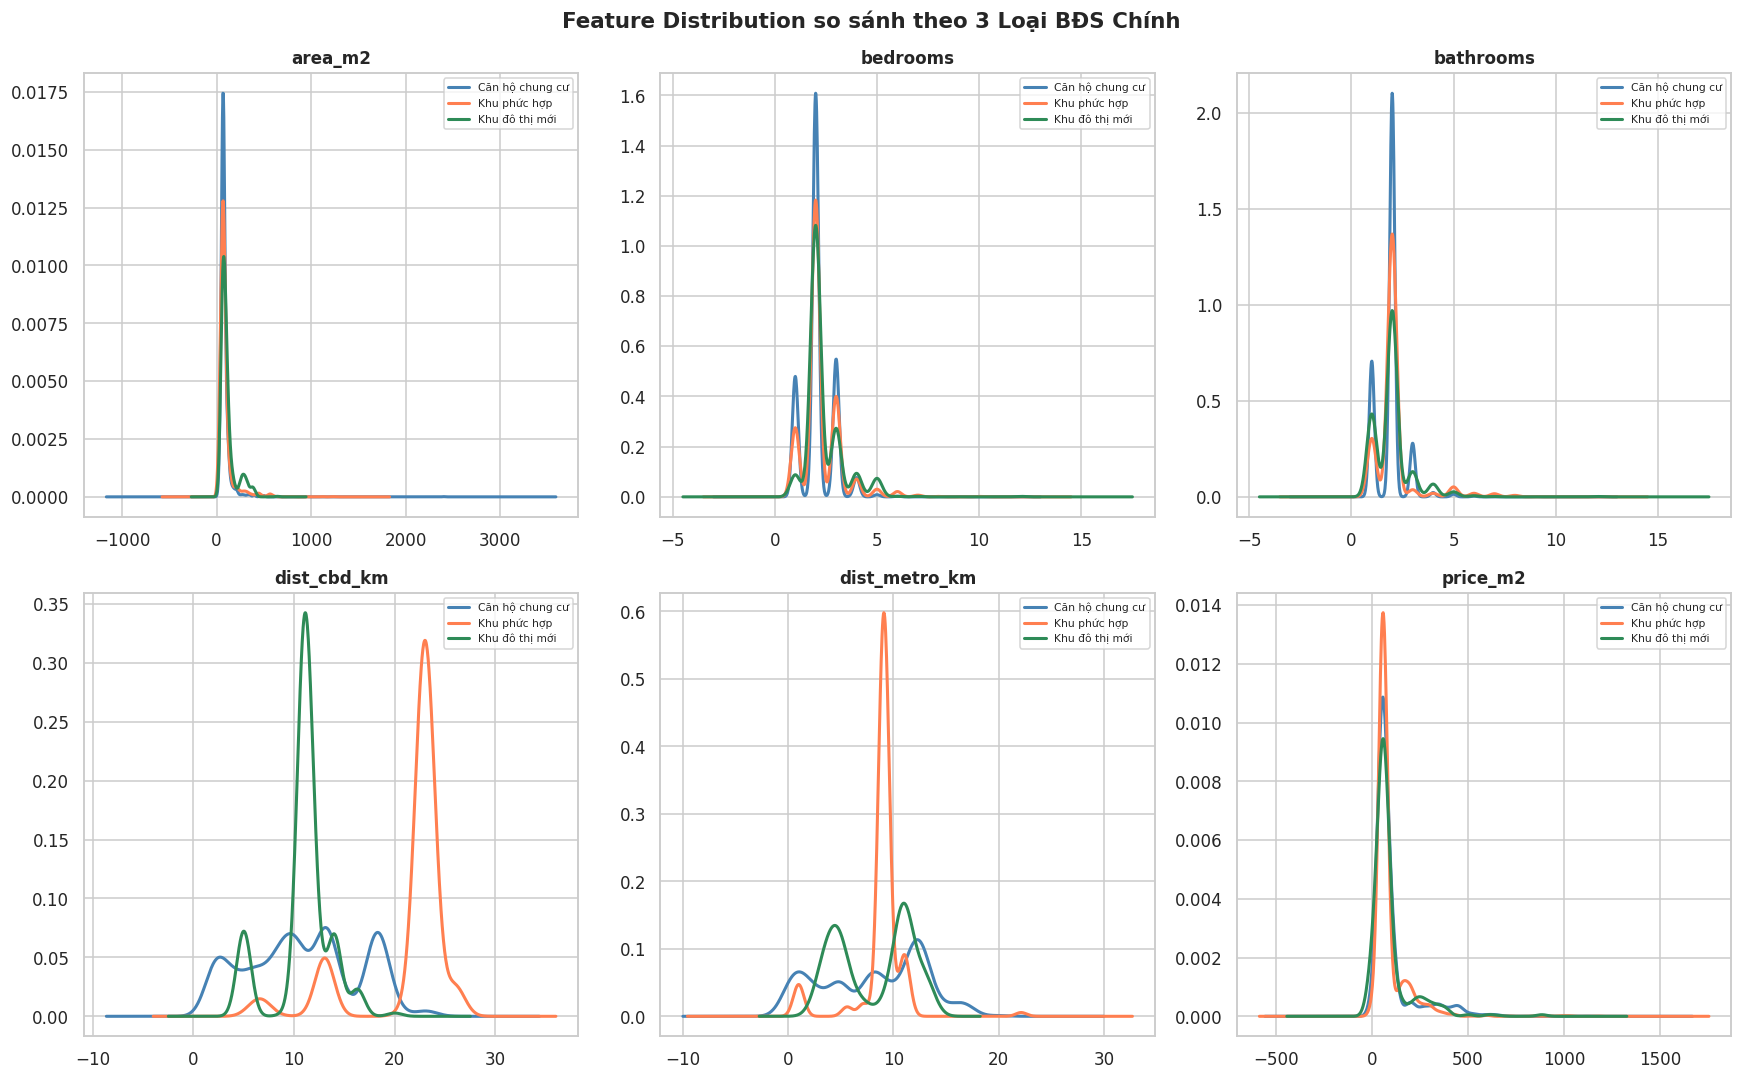

In [ ]:
# ============================================================
# CELL 5B: Feature differences across Property Types
# ============================================================
main3 = ['Căn hộ chung cư', 'Khu phức hợp', 'Khu đô thị mới']
df3 = df[df['project_type'].isin(main3)]

compare_features = ['area_m2', 'bedrooms', 'bathrooms', 'dist_cbd_km', 'dist_metro_km', 'price_m2']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors_t = {'Căn hộ chung cư': 'steelblue', 'Khu phức hợp': 'coral', 'Khu đô thị mới': 'seagreen'}

for ax, feat in zip(axes, compare_features):
    for ptype in main3:
        sub = df3[df3['project_type']==ptype][feat].dropna()
        sub.plot(kind='kde', ax=ax, color=colors_t[ptype], lw=2, label=ptype)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_ylabel('')

plt.suptitle('Feature Distribution so sánh theo 3 Loại BĐS Chính', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## SECTION 6 — CORRELATION & RELATIONSHIP ANALYSIS

### Cell 6A — Correlation Matrix (Pearson)

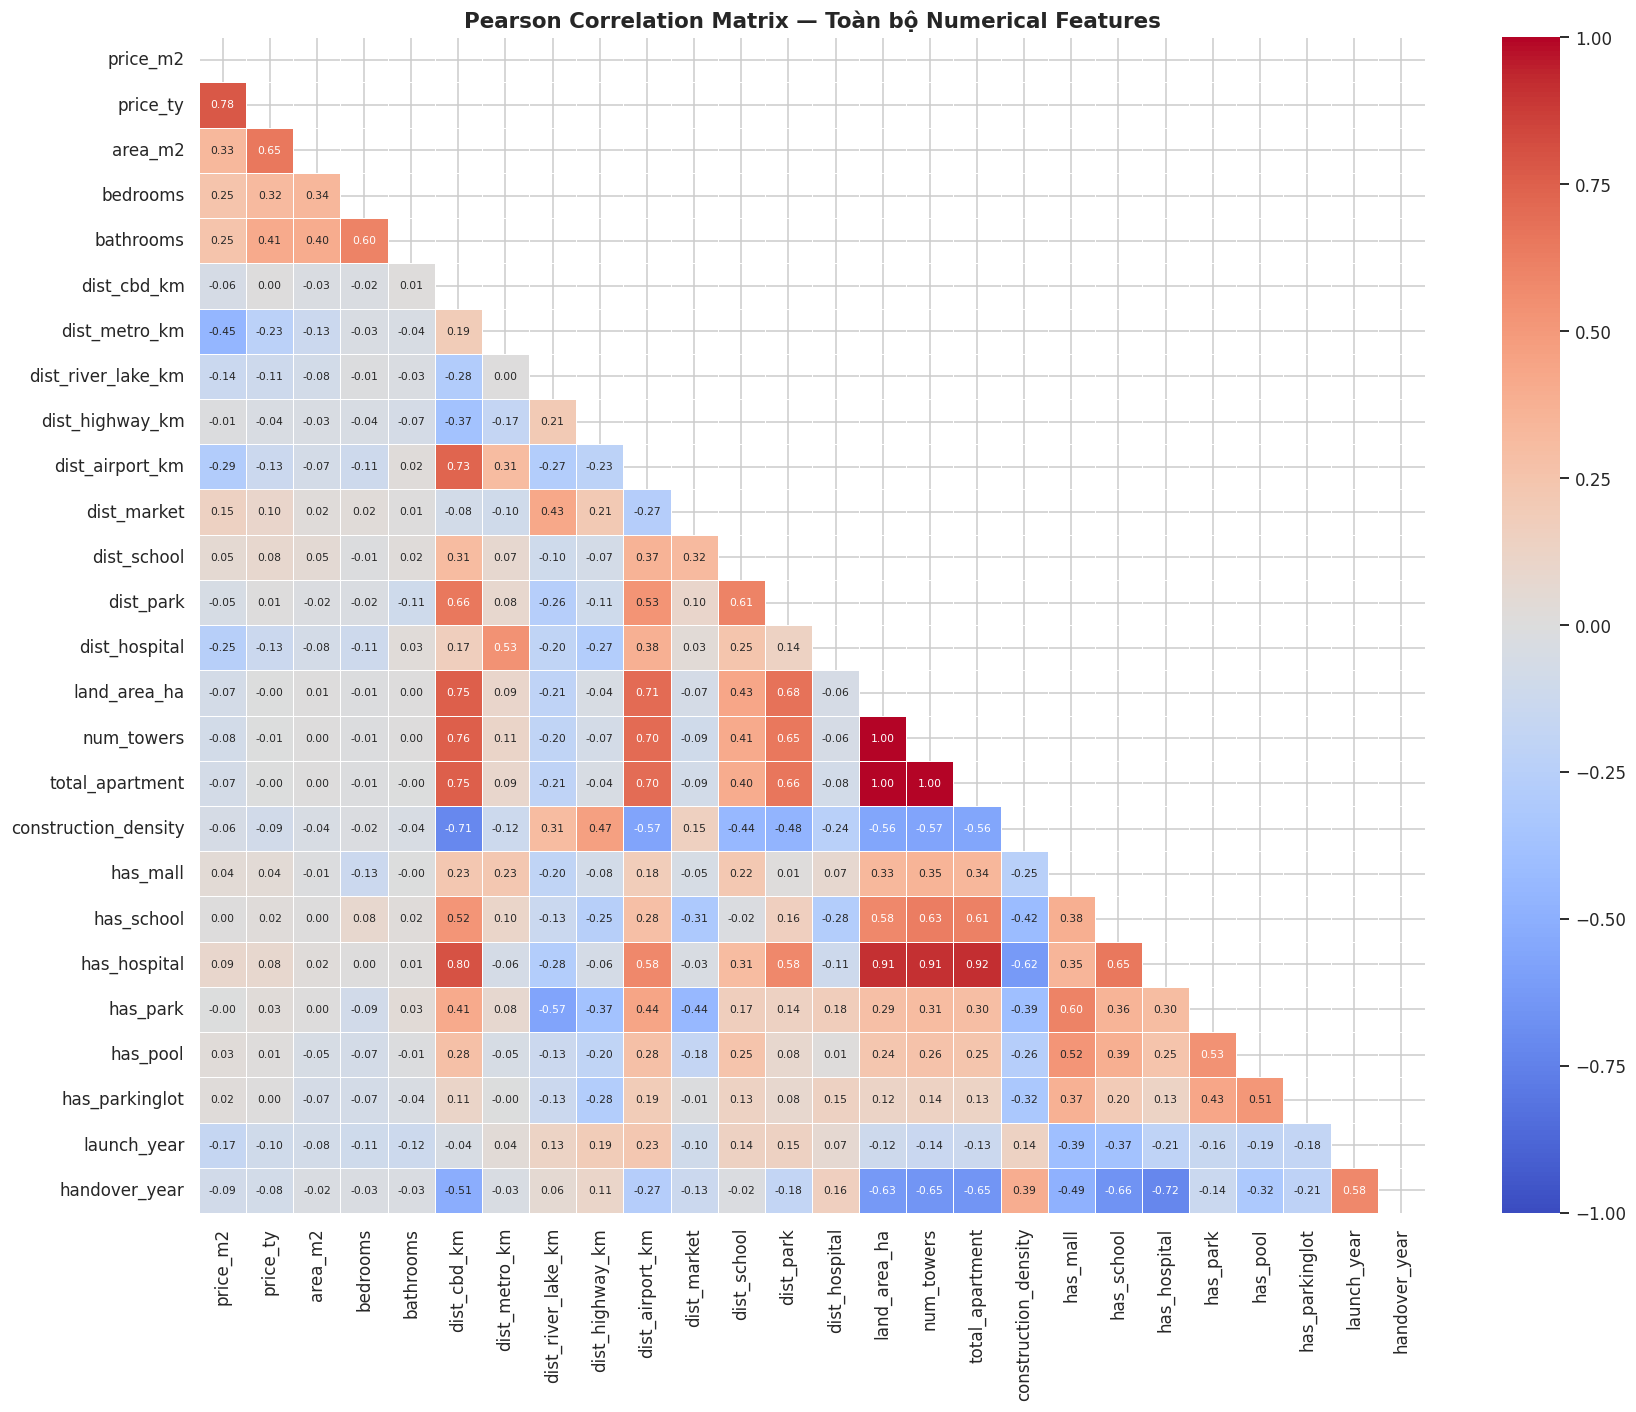

In [ ]:
# ============================================================
# CELL 6A: Correlation Matrix — Pearson
# ============================================================
corr_features = [
    'price_m2', 'price_ty', 'area_m2',
    'bedrooms', 'bathrooms',
    'dist_cbd_km', 'dist_metro_km', 'dist_river_lake_km',
    'dist_highway_km', 'dist_airport_km',
    'dist_market', 'dist_school', 'dist_park', 'dist_hospital',
    'land_area_ha', 'num_towers', 'total_apartment',
    'construction_density',
    'has_mall', 'has_school', 'has_hospital',
    'has_park', 'has_pool', 'has_parkinglot',
    'launch_year', 'handover_year'
]
corr_df = df[corr_features].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', center=0,
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Pearson Correlation Matrix — Toàn bộ Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Cell 6B — Target Correlation Ranking

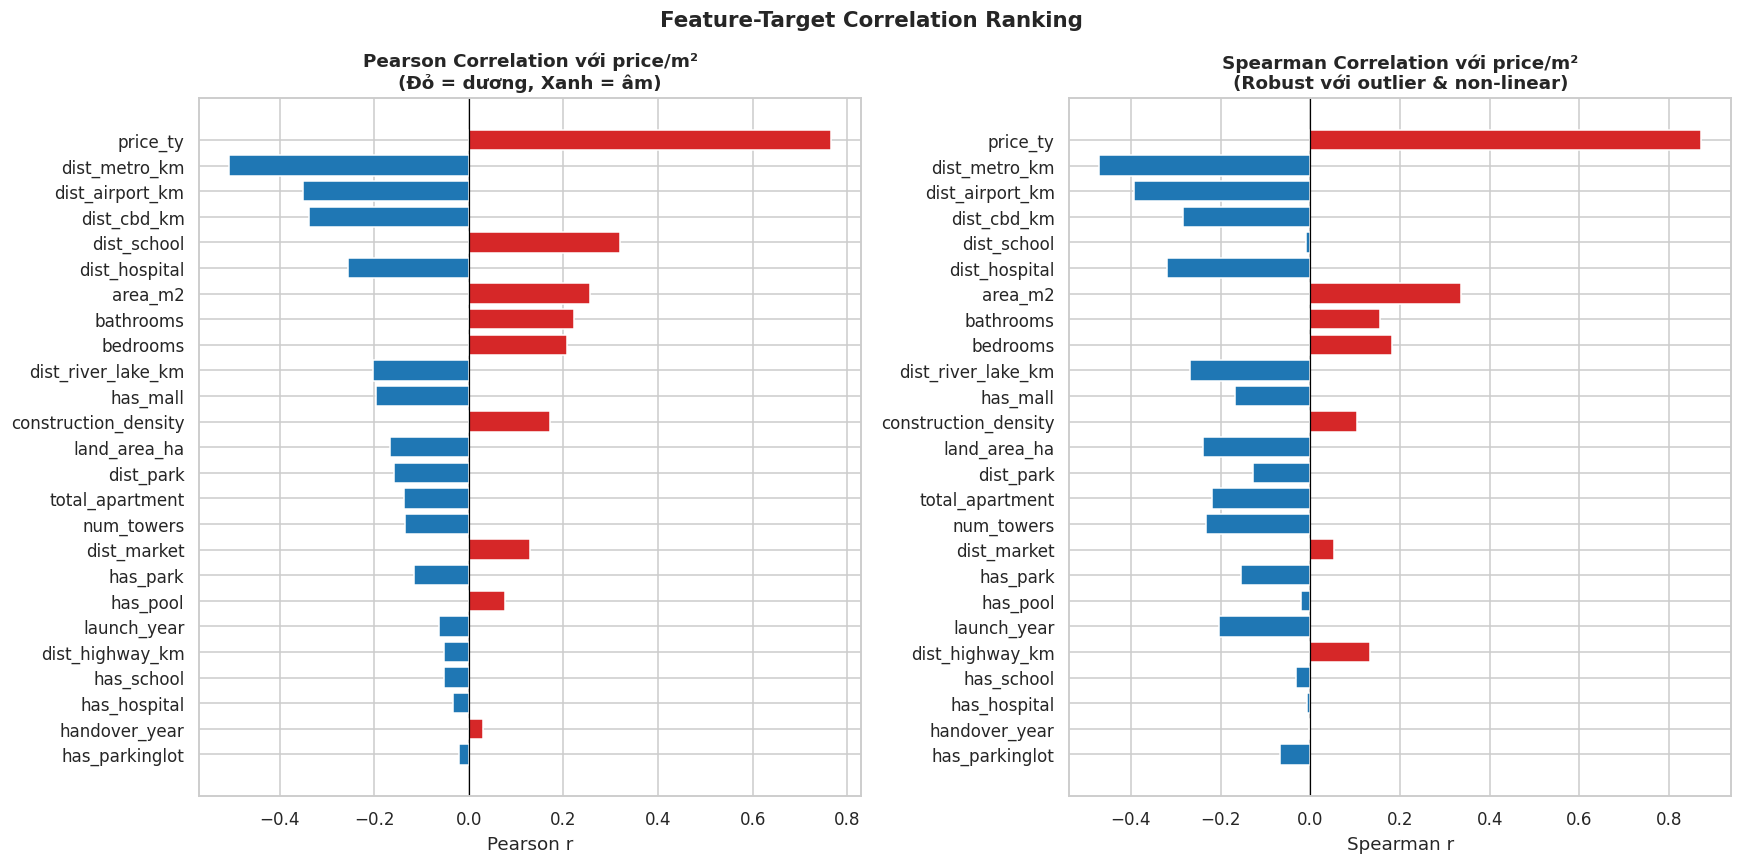

TOP 10 FEATURES tương quan với price/m² (theo |Pearson r|):


,Feature,Pearson_r,Spearman_r,Abs_Pearson
0,price_ty,0.766,0.872,0.766
1,dist_metro_km,-0.507,-0.471,0.507
2,dist_airport_km,-0.351,-0.393,0.351
3,dist_cbd_km,-0.338,-0.284,0.338
4,dist_school,0.319,-0.009,0.319
5,dist_hospital,-0.256,-0.319,0.256
6,area_m2,0.255,0.336,0.255
7,bathrooms,0.223,0.156,0.223
8,bedrooms,0.207,0.182,0.207
9,dist_river_lake_km,-0.202,-0.269,0.202


In [ ]:
# ============================================================
# CELL 6B: Target Correlation — Ranking theo |r|
# ============================================================
features_corr = [f for f in corr_features if f != 'price_m2']
target = df['price_m2'].dropna()

pearson_corr, spearman_corr = {}, {}
for feat in features_corr:
    merged = df[[feat, 'price_m2']].dropna()
    if len(merged) > 10:
        r_p, _ = stats.pearsonr(merged[feat], merged['price_m2'])
        r_s, _ = stats.spearmanr(merged[feat], merged['price_m2'])
        pearson_corr[feat] = r_p
        spearman_corr[feat] = r_s

corr_rank = pd.DataFrame({
    'Feature': list(pearson_corr.keys()),
    'Pearson_r': list(pearson_corr.values()),
    'Spearman_r': list(spearman_corr.values())
})
corr_rank['Abs_Pearson'] = corr_rank['Pearson_r'].abs()
corr_rank = corr_rank.sort_values('Abs_Pearson', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colors_p = ['#d62728' if v > 0 else '#1f77b4' for v in corr_rank['Pearson_r']]
axes[0].barh(corr_rank['Feature'][::-1], corr_rank['Pearson_r'][::-1], color=colors_p[::-1])
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Pearson r')
axes[0].set_title('Pearson Correlation với price/m²\n(Đỏ = dương, Xanh = âm)', fontsize=12, fontweight='bold')

colors_s = ['#d62728' if v > 0 else '#1f77b4' for v in corr_rank['Spearman_r']]
axes[1].barh(corr_rank['Feature'][::-1], corr_rank['Spearman_r'][::-1], color=colors_s[::-1])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Spearman r')
axes[1].set_title('Spearman Correlation với price/m²\n(Robust với outlier & non-linear)', fontsize=12, fontweight='bold')

plt.suptitle('Feature-Target Correlation Ranking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('TOP 10 FEATURES tương quan với price/m² (theo |Pearson r|):')
top10_corr = (
    corr_rank.head(10)
    .round(3)
    .reset_index(drop=True)
)

display(top10_corr.style
        .background_gradient(subset=['Pearson_r'], cmap='coolwarm')
        .background_gradient(subset=['Spearman_r'], cmap='coolwarm')
        .format({
            'Pearson_r': '{:.3f}',
            'Spearman_r': '{:.3f}',
            'Abs_Pearson': '{:.3f}'
        }))

### Cell 6C — Scatter Plots: Top Features vs Target

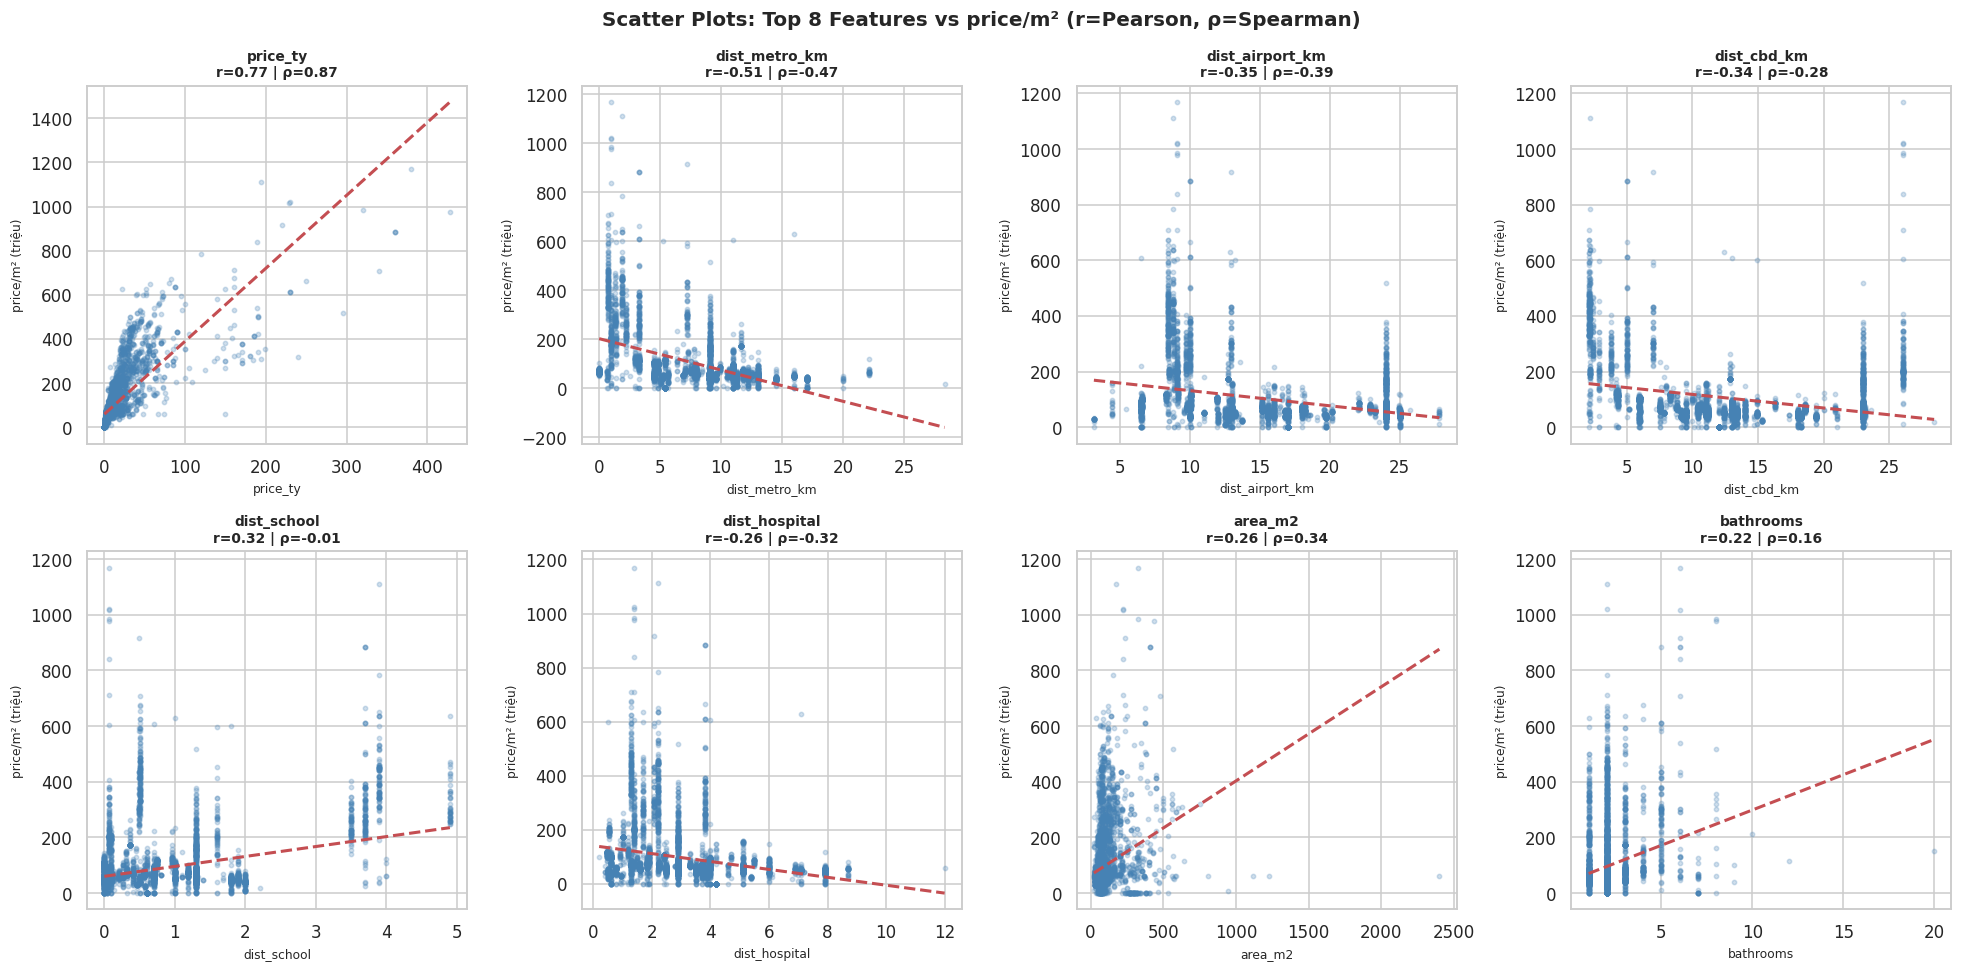

In [ ]:
# ============================================================
# CELL 6C: Scatter Plots — Top 8 features vs target
# ============================================================
top8 = corr_rank.head(8)['Feature'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top8):
    merged = df[[feat, 'price_m2']].dropna()
    ax.scatter(merged[feat], merged['price_m2'], alpha=0.25, s=8, color='steelblue')
    # Trend
    z = np.polyfit(merged[feat], merged['price_m2'], 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(merged[feat].min(), merged[feat].max(), 100)
    ax.plot(x_line, p_fit(x_line), 'r--', lw=2)
    r_p = pearson_corr.get(feat, 0)
    r_s = spearman_corr.get(feat, 0)
    ax.set_title(f'{feat}\nr={r_p:.2f} | ρ={r_s:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('price/m² (triệu)', fontsize=8)

plt.suptitle('Scatter Plots: Top 8 Features vs price/m² (r=Pearson, ρ=Spearman)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Cell 6D — Multicollinearity Check (VIF)

HIGH CORRELATION PAIRS (|r| > 0.6) — tiềm năng multicollinearity:


,Feature_1,Feature_2,Corr
0,num_towers,total_apartment,0.999
1,land_area_ha,num_towers,0.996
2,land_area_ha,total_apartment,0.993
3,num_towers,has_hospital,0.913
4,total_apartment,has_hospital,0.809
5,land_area_ha,has_hospital,0.775
6,price_m2,price_ty,0.766
7,dist_cbd_km,num_towers,0.760
8,dist_cbd_km,dist_airport_km,0.757
9,dist_cbd_km,total_apartment,0.749


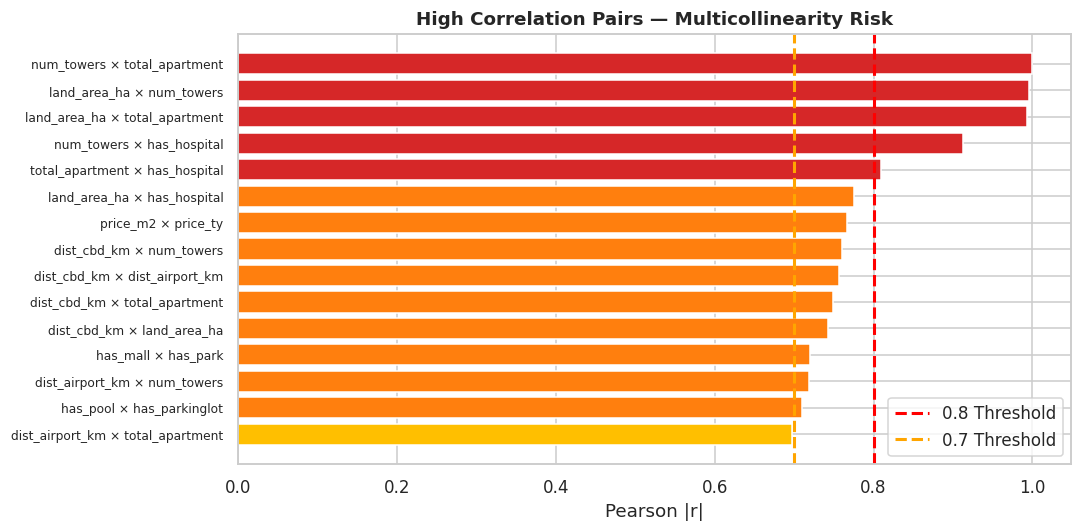

In [ ]:
# ============================================================
# CELL 6D: Multicollinearity — VIF & High Correlation Pairs
# ============================================================
from itertools import combinations

# High correlation pairs (potential redundant features)
corr_mat = df[corr_features].corr().abs()
high_corr_pairs = []
for f1, f2 in combinations(corr_features, 2):
    val = corr_mat.loc[f1, f2]
    if val > 0.6 and f1 != f2:
        high_corr_pairs.append({'Feature_1': f1, 'Feature_2': f2, 'Corr': round(val, 3)})

hc_df = pd.DataFrame(high_corr_pairs).sort_values('Corr', ascending=False)
print('HIGH CORRELATION PAIRS (|r| > 0.6) — tiềm năng multicollinearity:')
display(
    hc_df.reset_index(drop=True)
         .style
         .background_gradient(subset=['Corr'], cmap='Reds')
         .format({'Corr': '{:.3f}'})
)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
if len(hc_df) > 0:
    hc_df_plot = hc_df.head(15)
    labels = [f"{r['Feature_1']}\nvs\n{r['Feature_2']}" for _, r in hc_df_plot.iterrows()]
    colors_hc = ['#d62728' if v > 0.8 else '#ff7f0e' if v > 0.7 else '#ffbf00' for v in hc_df_plot['Corr']]
    ax.barh(range(len(hc_df_plot)), hc_df_plot['Corr'][::-1], color=colors_hc[::-1])
    ax.set_yticks(range(len(hc_df_plot)))
    ax.set_yticklabels([f"{r['Feature_1']} × {r['Feature_2']}" for _, r in hc_df_plot[::-1].iterrows()], fontsize=8)
    ax.axvline(0.8, color='red',    ls='--', lw=2, label='0.8 Threshold')
    ax.axvline(0.7, color='orange', ls='--', lw=2, label='0.7 Threshold')
    ax.set_xlabel('Pearson |r|')
    ax.set_title('High Correlation Pairs — Multicollinearity Risk', fontsize=12, fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.show()

---
## SECTION 7 — FEATURE CONTRIBUTION PREPARATION

### Cell 7A — Categorical Feature Analysis (cardinality, importance)

,Feature,Unique,Null_%,ANOVA_F,p_value,Significant,Encoding
0,ward,48,0.1%,277.4,0.00e+00,✅,Target Encoding
1,project_name,83,0.0%,231.1,0.00e+00,✅,Target Encoding
2,ownership,20,3.6%,204.6,0.00e+00,✅,Target Encoding
3,investor,58,1.8%,163.1,0.00e+00,✅,Target Encoding
4,listing_type,5,0.0%,93.7,1.49e-77,✅,One-Hot Encoding
5,direction,9,0.0%,14.9,9.03e-22,✅,One-Hot Encoding
6,legal_status,3,0.0%,10.4,3.14e-05,✅,One-Hot Encoding
7,project_type,7,0.0%,9.9,2.14e-09,✅,One-Hot Encoding
8,furniture_status,4,0.0%,5.1,1.56e-03,❌,One-Hot Encoding
9,project_status,2,0.0%,1.7,1.91e-01,❌,One-Hot Encoding


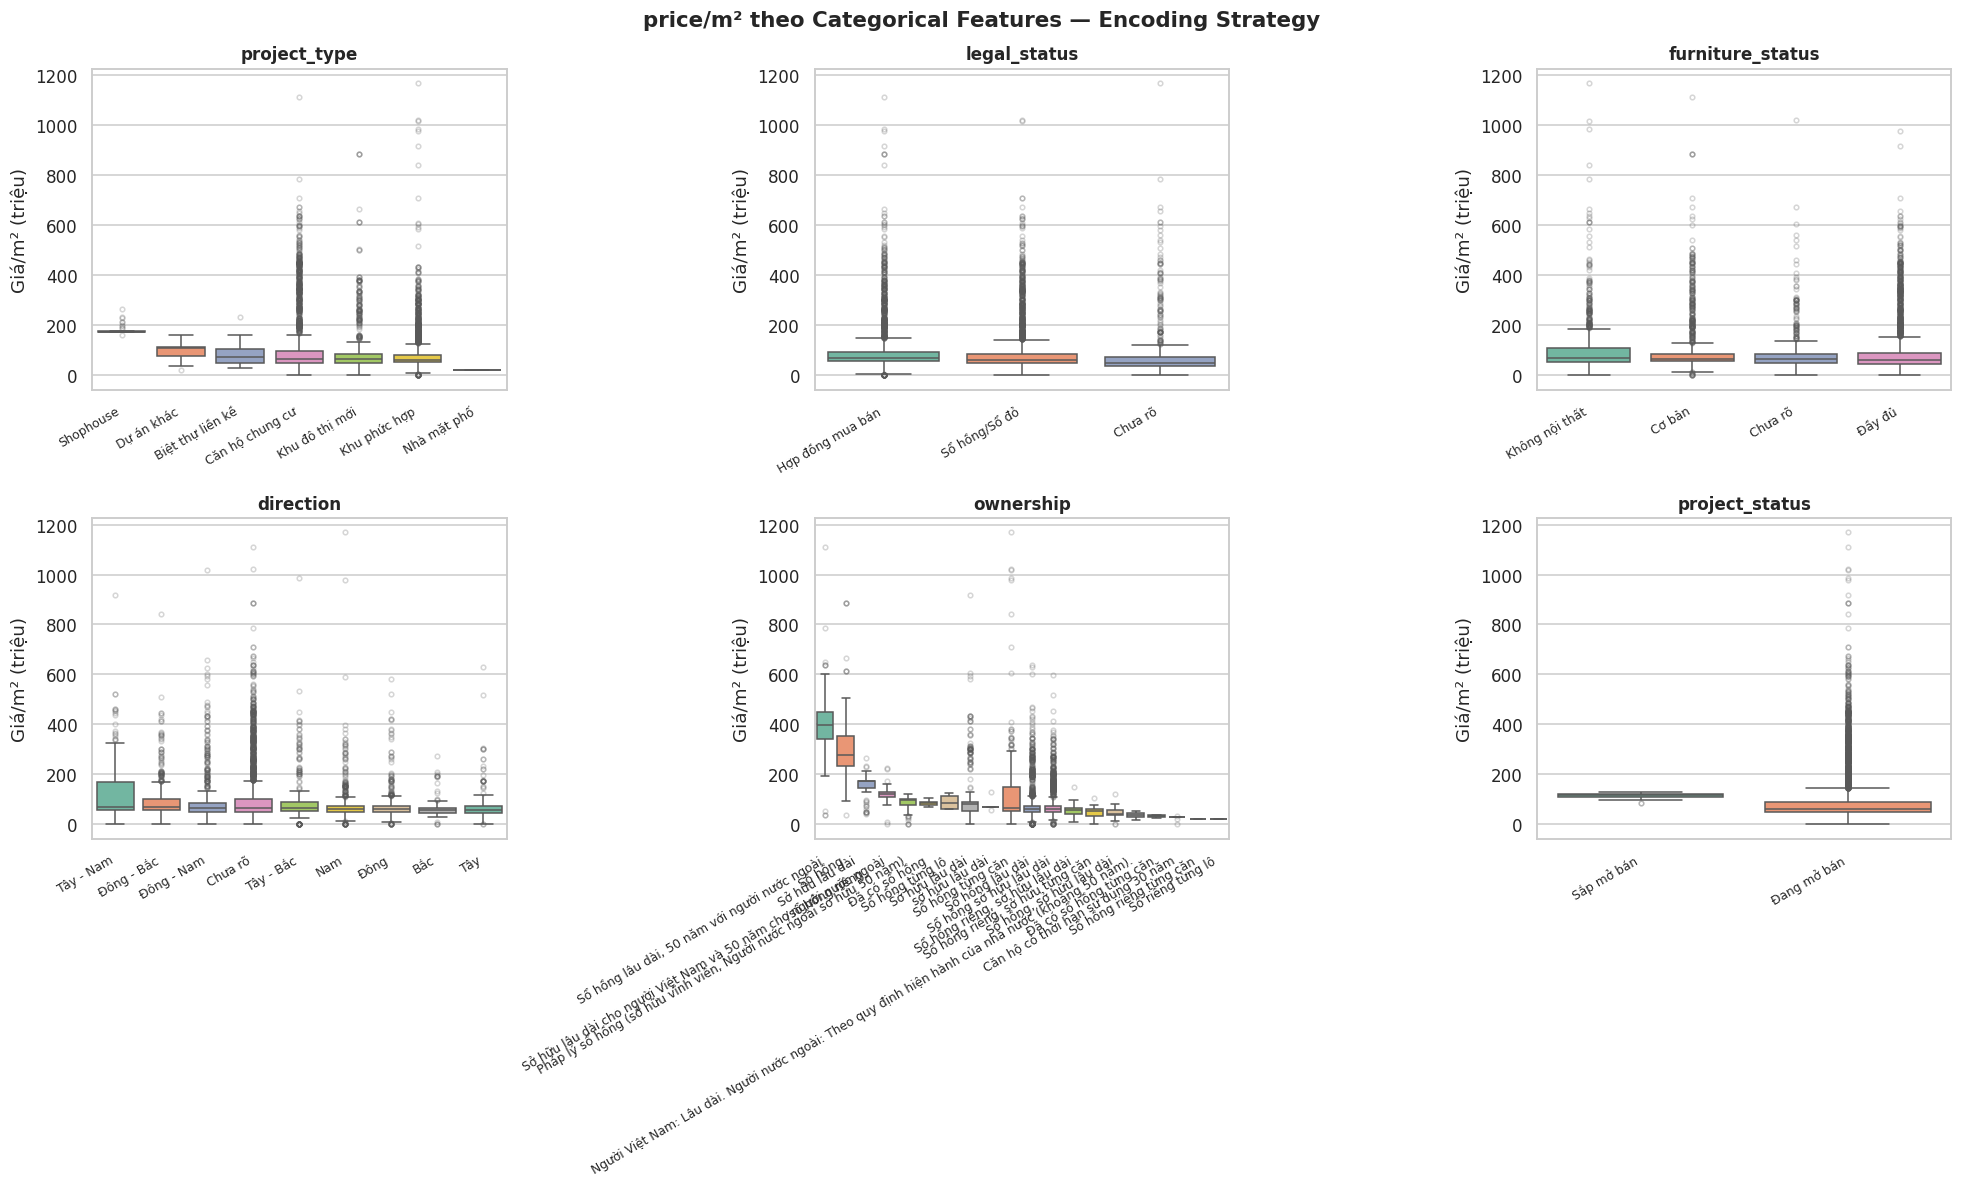

In [ ]:
# ============================================================
# CELL 7A: Categorical Feature Analysis — Cardinality & Encoding
# ============================================================
cat_useful = ['project_name', 'project_type', 'project_status', 'investor',
              'ward', 'legal_status', 'furniture_status', 'direction',
              'ownership', 'listing_type']

cat_analysis = []
for col in cat_useful:
    uniq = df[col].nunique()
    null_pct = df[col].isnull().mean() * 100
    # ANOVA-style: eta-squared (effect size)
    groups_a = [g['price_m2'].dropna().values for _, g in df.groupby(col) if len(g) >= 3]
    if len(groups_a) >= 2:
        f_s, p_s = stats.f_oneway(*groups_a)
    else:
        f_s, p_s = 0, 1

    if uniq <= 15: enc = 'One-Hot Encoding'
    elif uniq <= 200: enc = 'Target Encoding'
    else: enc = 'Target Encoding / Hash'

    cat_analysis.append({
        'Feature': col, 'Unique': uniq,
        'Null_%': round(null_pct, 1),
        'ANOVA_F': round(f_s, 1), 'p_value': f'{p_s:.2e}',
        'Significant': '✅' if p_s < 0.001 else '❌',
        'Encoding': enc
    })

cat_df = pd.DataFrame(cat_analysis).sort_values('ANOVA_F', ascending=False).reset_index(drop=True)
display(
    cat_df.style
          .background_gradient(subset=['ANOVA_F'], cmap='Blues')
          .format({
              'Null_%': '{:.1f}%',
              'ANOVA_F': '{:.1f}'
          })
)

# Visualize: price/m² theo top categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

top_cats = ['project_type', 'legal_status', 'furniture_status', 'direction', 'ownership', 'project_status']
for ax, col in zip(axes, top_cats):
    order = df.groupby(col)['price_m2'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='price_m2', order=order, ax=ax,
                palette='Set2', flierprops=dict(marker='o', alpha=0.25, markersize=3))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Giá/m² (triệu)')

plt.suptitle('price/m² theo Categorical Features — Encoding Strategy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Cell 7B — Feature Engineering Ideas

ENGINEERED FEATURES — Correlation với price/m²:


,Feature,Pearson_r,Spearman_r,n
0,avg_dist_to_facilities,-0.446,-0.410,"6,430"
1,project_size_index,-0.114,-0.240,"5,138"
2,project_age,0.062,0.205,"5,966"
3,rooms_total,0.234,0.196,"6,435"
4,amenity_score,-0.081,-0.084,"6,435"
5,build_duration,0.046,0.076,"5,879"


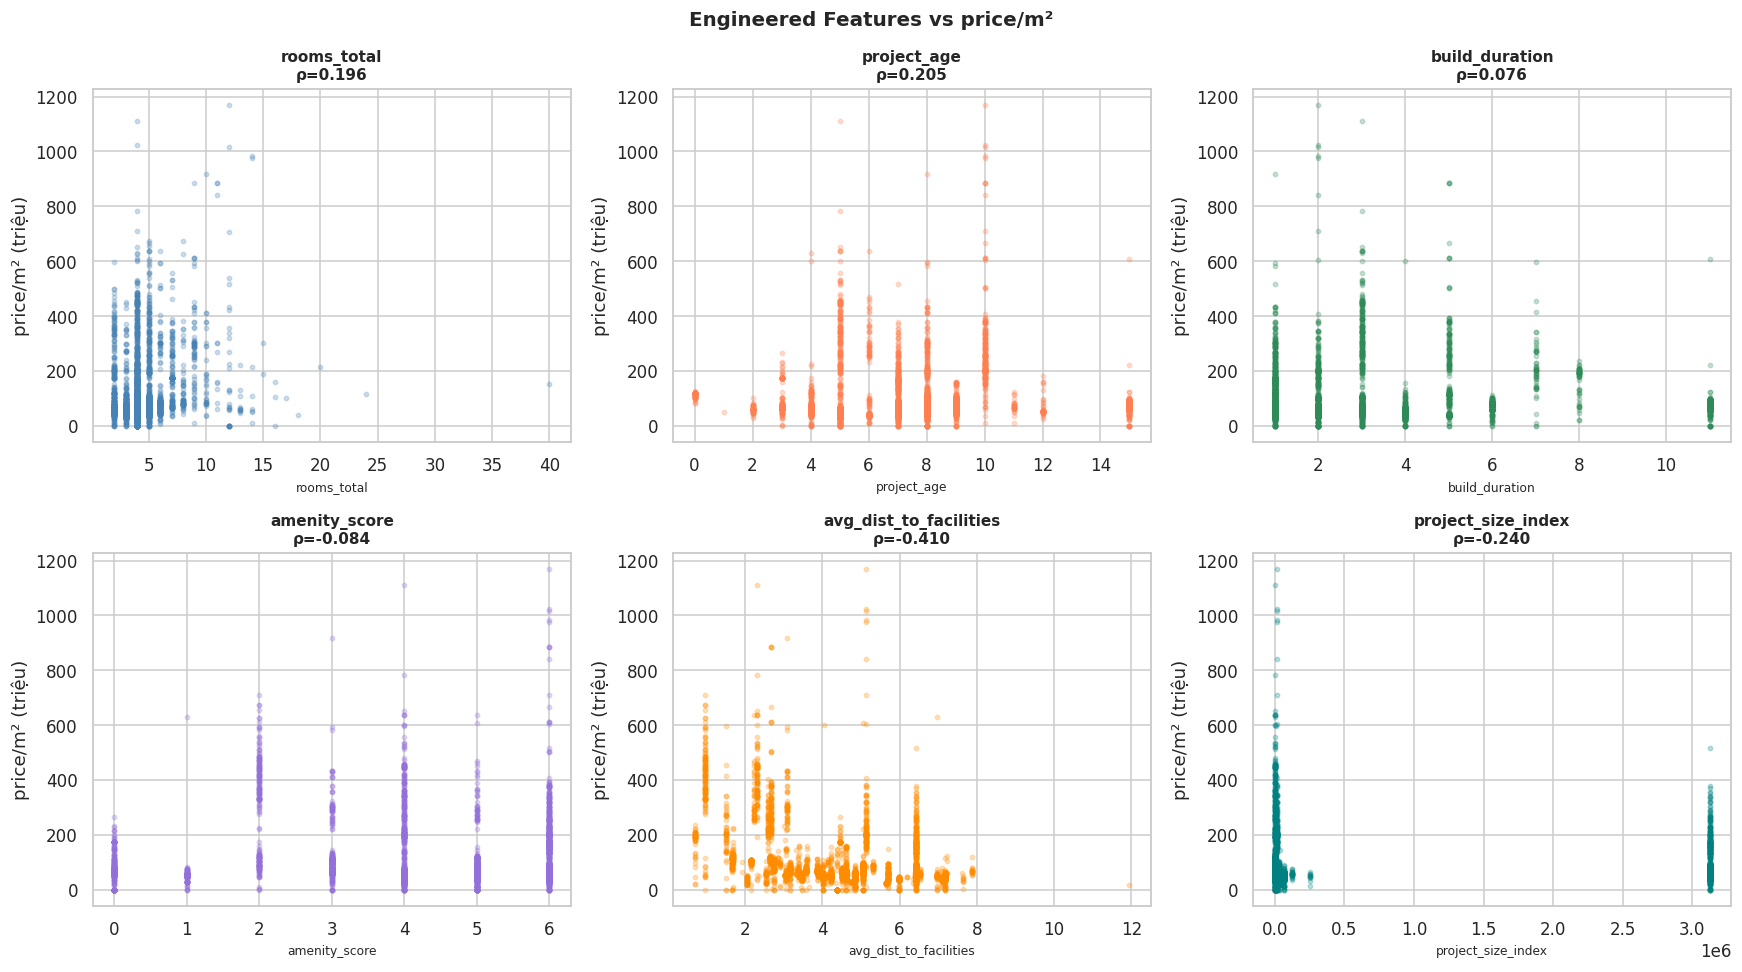

In [ ]:
# ============================================================
# CELL 7B: Feature Engineering — Tạo & Test features mới
# ============================================================
df_fe = df.copy()

# 1. Rooms total
df_fe['rooms_total'] = df_fe['bedrooms'] + df_fe['bathrooms']

# 2. Project age (tính đến 2026)
df_fe['project_age'] = 2026 - df_fe['launch_year']

# 3. Years to handover (từ launch đến handover)
df_fe['build_duration'] = df_fe['handover_year'] - df_fe['launch_year']

# 4. Amenity score: tổng tiện ích
amenity_cols = ['has_mall','has_school','has_hospital','has_park','has_pool','has_parkinglot']
df_fe['amenity_score'] = df_fe[amenity_cols].sum(axis=1)

# 5. Distance composite (avg distance to all facilities)
dist_cols_all = ['dist_cbd_km','dist_metro_km','dist_market','dist_school','dist_park','dist_hospital']
df_fe['avg_dist_to_facilities'] = df_fe[dist_cols_all].mean(axis=1)

# 6. Project size index
df_fe['project_size_index'] = df_fe['num_towers'] * df_fe['total_apartment'].fillna(0)

# Test correlation của new features với target
new_features = ['rooms_total', 'project_age', 'build_duration', 'amenity_score',
                'avg_dist_to_facilities', 'project_size_index']

fe_corr = []
for feat in new_features:
    merged = df_fe[[feat, 'price_m2']].dropna()
    if len(merged) > 10:
        r_p, _ = stats.pearsonr(merged[feat], merged['price_m2'])
        r_s, _ = stats.spearmanr(merged[feat], merged['price_m2'])
        fe_corr.append({'Feature': feat, 'Pearson_r': round(r_p,3), 'Spearman_r': round(r_s,3), 'n': len(merged)})

fe_df = pd.DataFrame(fe_corr).sort_values('Spearman_r', key=abs, ascending=False)
print('ENGINEERED FEATURES — Correlation với price/m²:')
display(
    fe_df.reset_index(drop=True)
         .style
         .background_gradient(subset=['Pearson_r'], cmap='coolwarm')
         .background_gradient(subset=['Spearman_r'], cmap='coolwarm')
         .format({
             'Pearson_r': '{:.3f}',
             'Spearman_r': '{:.3f}',
             'n': '{:,}'
         })
)

# Visualize top engineered features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors_fe = ['steelblue','coral','seagreen','mediumpurple','darkorange','teal']

for ax, feat, color in zip(axes, new_features, colors_fe):
    merged = df_fe[[feat, 'price_m2']].dropna()
    ax.scatter(merged[feat], merged['price_m2'], alpha=0.25, s=8, color=color)
    r_s = fe_df[fe_df['Feature']==feat]['Spearman_r'].values
    rs_label = f'ρ={r_s[0]:.3f}' if len(r_s)>0 else ''
    ax.set_title(f'{feat}\n{rs_label}', fontsize=10, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('price/m² (triệu)')

plt.suptitle('Engineered Features vs price/m²', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Cell 7C — Feature Selection Summary: Keep / Remove / Transform / Encode

In [ ]:
# ============================================================
# CELL 7C: Feature Decision Table — WHY cho từng quyết định
# ============================================================
decisions = [
    # (Feature, Action, Why)
    ('area_m2',              'KEEP + log1p()',      'Quan trọng, skew cao → log transform'),
    ('bedrooms',             'KEEP + log1p()',      'Quan trọng, skew=2.9'),
    ('bathrooms',            'KEEP + log1p()',      'Tương quan với bedrooms nhưng vẫn có info riêng'),
    ('rooms_total',          'KEEP (engineered)',   'Giảm multicollinearity giữa bed & bath'),
    ('dist_cbd_km',          'KEEP',                'Tương quan âm với giá, phản ánh vị trí trung tâm'),
    ('dist_metro_km',        'KEEP',                'Giao thông công cộng ảnh hưởng giá'),
    ('dist_river_lake_km',   'KEEP + log1p()',      'Skew cao (2.98), view sông ảnh hưởng giá'),
    ('dist_market',          'KEEP + log1p()',      'Skew 2.47'),
    ('dist_school',          'KEEP + log1p()',      'Skew 1.58'),
    ('dist_park',            'KEEP',                'Skew 0.61, ok'),
    ('dist_hospital',        'KEEP',                'Skew 1.1, ok'),
    ('dist_highway_km',      'KEEP + log1p()',      'Skew 1.33'),
    ('dist_airport_km',      'KEEP',                'Symmetric, giữ'),
    ('amenity_score',        'KEEP (engineered)',   'Summarizes has_* features'),
    ('has_mall','has_pool','has_parkinglot',
                             'KEEP hoặc dùng score', 'Binary, ít cardinality'),
    ('land_area_ha',         'KEEP',                'Project scale indicator, null 0.2%'),
    ('num_towers',           'KEEP + impute',       '20% null → impute median theo project_type'),
    ('total_apartment',      'KEEP + impute',       '4.3% null → impute median'),
    ('construction_density', 'KEEP + log1p()',      'Skew 2.44'),
    ('project_age',          'KEEP (engineered)',   '= 2026 - launch_year'),
    ('avg_dist_to_facilities','KEEP (engineered)',  'Composite distance score'),
    ('project_name',         'Target Encoding',     'Cardinality cao, ANOVA significant'),
    ('project_type',         'One-Hot Encoding',    'Cardinality thấp (7), significant'),
    ('project_status',       'One-Hot Encoding',    'Cardinality thấp, significant'),
    ('legal_status',         'One-Hot Encoding',    'Categorical, significant'),
    ('furniture_status',     'One-Hot Encoding',    'Categorical, significant'),
    ('direction',            'One-Hot Encoding',    'Categorical, moderate effect'),
    ('ownership',            'One-Hot Encoding',    'Categorical, có null → impute mode'),
    ('investor',             'Target Encoding',     'Cardinality cao, significant'),
    ('ward',                 'Target Encoding',     'Cardinality cao → location proxy'),
    ('listing_type',         'One-Hot Encoding',    'Signal về chất lượng listing'),
    ('longitude','latitude', 'KEEP cả 2',           'Geospatial info, quan trọng cho location-based model'),
    # REMOVE
    ('source_listing_id',    'REMOVE',              'ID, không có predictive power'),
    ('listing_url',          'REMOVE',              'Text URL'),
    ('title','listing_description','project_description', 'REMOVE (optional NLP)', 'Cần NLP nếu muốn dùng'),
    ('contact_name','contact_phone_masked', 'REMOVE', 'Thông tin cá nhân, không liên quan giá'),
    ('posted_at','expired_at','snapshot_date', 'REMOVE hoặc extract tháng/năm', 'Timestamp, extract nếu cần seasonality'),
    ('note',                 'REMOVE',              '98% null'),
    ('price_total_vnd',      'REMOVE khi dự đoán',  'Leakage: derive từ price_m2 × area'),
    ('price_ty',             'REMOVE khi dự đoán',  'Leakage: same as price_total_vnd'),
]

rows = []
for d in decisions:
    if len(d) == 3:
        rows.append({'Feature': d[0], 'Action': d[1], 'Why': d[2]})
    elif len(d) == 4:
        rows.append({'Feature': d[0], 'Action': d[1], 'Why': d[3]})

dec_df = pd.DataFrame(rows)
# Color coding
print('='*80)
print('FEATURE DECISION TABLE')
print('='*80)
for _, row in dec_df.iterrows():
    action = row['Action']
    icon = '✅' if 'KEEP' in action else ('🔤' if 'Encoding' in action else ('⚙️' if 'engineered' in action else '❌'))
    print(f"{icon} [{action:<30}] {row['Feature']:<35} → {row['Why']}")

FEATURE DECISION TABLE
✅ [KEEP + log1p()                ] area_m2                             → Quan trọng, skew cao → log transform
✅ [KEEP + log1p()                ] bedrooms                            → Quan trọng, skew=2.9
✅ [KEEP + log1p()                ] bathrooms                           → Tương quan với bedrooms nhưng vẫn có info riêng
✅ [KEEP (engineered)             ] rooms_total                         → Giảm multicollinearity giữa bed & bath
✅ [KEEP                          ] dist_cbd_km                         → Tương quan âm với giá, phản ánh vị trí trung tâm
✅ [KEEP                          ] dist_metro_km                       → Giao thông công cộng ảnh hưởng giá
✅ [KEEP + log1p()                ] dist_river_lake_km                  → Skew cao (2.98), view sông ảnh hưởng giá
✅ [KEEP + log1p()                ] dist_market                         → Skew 2.47
✅ [KEEP + log1p()                ] dist_school                         → Skew 1.58
✅ [KEEP                       